[Sumber data California Housing Price](https://drive.google.com/drive/folders/19YA_f36uGR86hTnZuX-Ech59s3AFzXXo) 

### **Contents**

1. Business Problem Understanding
2. Data Understanding
3. Data Preprocessing
4. Modeling
5. Conclusion
6. Recommendation

****

### **Business Problem Understanding**

**Context**

Harga rumah merupakan salah satu indikator penting dalam perekonomian suatu wilayah. Di Amerika Serikat, khususnya di California, harga rumah sering menjadi perhatian karena wilayah ini memiliki populasi besar, tingkat urbanisasi tinggi, serta keterkaitan dengan pusat industri seperti teknologi di Silicon Valley maupun hiburan di Los Angeles.
Harga rumah di California sendiri cenderung sangat fluktuatif dan jauh lebih tinggi dibandingkan rata-rata nasional. 

Menurut Forbes (2024), median harga rumah di California mencapai sekitar US$ 906.500, sementara median harga rumah nasional berada di kisaran US$ 402.343. Perbedaan ini menunjukkan bahwa rumah di California hampir dua kali lipat lebih mahal dibandingkan rata-rata di seluruh Amerika Serikat. 

Untuk menilai apakah suatu rumah dijual dengan harga yang wajar, dibutuhkan alat atau metode yang dapat mengidentifikasi apakah harga tersebut underpriced (lebih murah dari seharusnya) atau overpriced (lebih mahal dari seharusnya). Secara tradisional, hal ini bisa dilakukan dengan membandingkan rumah sejenis di lokasi yang sama (comparative market analysis). Namun, pendekatan manual sering kali terbatas dan subjektif, karena tidak mempertimbangkan seluruh faktor yang kompleks dan saling berkaitan, seperti kondisi ekonomi, demografi, fasilitas umum, hingga tren pasar jangka panjang.


Di sinilah peran machine learning menjadi penting. Dengan machine learning, model dapat mempelajari pola dari berbagai faktor yang memengaruhi harga rumah, seperti lokasi, jumlah kamar, luas bangunan, jarak ke pusat kota, serta kondisi lingkungan sekitar. Model ini mampu memberikan prediksi harga yang lebih akurat, sehingga membantu pembeli untuk menghindari membeli rumah dengan harga terlalu tinggi, dan membantu penjual untuk menetapkan harga kompetitif agar rumah tidak undervalued. Selain itu, machine learning juga memungkinkan adanya sistem penilaian harga secara real-time, yang sangat relevan di pasar properti dinamis seperti California.

**Problem Statement**

Menentukan harga rumah yang wajar adalah masalah penting bagi penjual, pembeli, maupun pengembang. **Harga yang terlalu tinggi akan mengurangi minat pembeli, sementara harga yang terlalu rendah bisa merugikan pemilik rumah.** Dengan banyaknya faktor yang memengaruhi harga (seperti lokasi, jumlah kamar, kepadatan penduduk, dan kedekatan dengan laut), pendekatan manual akan sulit dilakukan. Oleh karena itu, diperlukan model prediksi harga rumah berbasis machine learning yang dapat memberikan estimasi nilai median harga rumah pada suatu distrik. Dalam analisis ini, fokus utama ditujukan pada penjual dan pengembang untuk menetapkan harga yang kompetitif serta membuat estimasi pasar yang mendukung perencanaan proyek dan strategi bisnis. Model machine learning tidak hanya membantu menentukan harga agar rumah lebih cepat terjual tanpa merugikan, tetapi juga memberikan pemahaman lebih baik mengenai preferensi pasar, mendukung analisis lokasi pengembangan, serta menjadi dasar yang kuat dalam negosiasi dengan calon pembeli maupun mitra bisnis.

**Goals**

Berdasarkan permasalahan tersebut, analisis ini perlu menghasilkan sebuah tool berupa model prediksi harga rumah, yang dapat membantu pemilik rumah maupun calon pembeli dalam menentukan harga rumah yang ideal. Dengan adanya estimasi harga yang didasarkan pada fitur-fitur penting seperti demografi, lokasi, dan kondisi lingkungan, model ini dapat memberikan gambaran nilai rumah yang lebih akurat. Selain itu, model ini juga diharapkan dapat menjadi sarana untuk mengetahui faktor-faktor yang mempengaruhi harga rumah.

**Analytic Approach**

Jadi, yang perlu kita lakukan adalah menganalisis data untuk menemukan pola dari fitur-fitur yang ada, yang membedakan nilai suatu properti dengan properti lainnya.
Selanjutnya, kita akan membangun sebuah model regresi yang dapat digunakan untuk memprediksi harga rumah di California, sehingga dapat menjadi tool pendukung bagi pihak-pihak yang berkepentingan, seperti calon pembeli, penjual, maupun pengembang, dalam menentukan estimasi nilai sebuah properti.

**Metric Evaluation**

Evaluasi metrik yang akan digunakan adalah RMSE, MAE, MSE, dan MAPE, di mana RMSE adalah nilai rataan akar kuadrat dari error, MAE adalah rataan nilai absolut dari error, MSE adalah MSE menghitung selisih antara nilai sebenarnya dan nilai prediksi, sedangkan MAPE adalah rataan persentase error yang dihasilkan oleh model regresi. Semakin kecil nilai RMSE, MAE, MSE dan MAPE yang dihasilkan, berarti model semakin akurat dalam memprediksi harga jual sesuai dengan limitasi fitur yang digunakan. 

Selain itu, kita juga bisa menggunakan nilai R-squared atau adj. R-squared jika model yang nanti terpilih sebagai final model adalah model linear. Nilai R-squared digunakan untuk mengetahui seberapa baik model dapat merepresentasikan varians keseluruhan data. Semakin mendekati 1, maka semakin fit pula modelnya terhadap data observasi. Namun, metrik ini tidak valid untuk model non-linear.

### **Data Understanding**

- Dataset merupakan data perumahan di California yang diperoleh dari sensus.
- Setiap baris data merepresentasikan informasi terkait kondisi demografi, lingkungan, serta karakteristik rumah pada suatu distrik di California.

**Attributes Information** 
| **Attribute** | **Data Type** | **Description** |
| --- | --- | --- |
| longitude	| Float	| Koordinat geografis bujur lokasi distrik |
| latitude	| Float	| Koordinat geografis lintang lokasi distrik |
| housing_median_age	| Float	| Usia median rumah di distrik (tahun) |
| total_rooms	| Float | 	Jumlah total ruangan di semua rumah dalam distrik |
| total_bedrooms	| Float	| Jumlah total kamar tidur di semua rumah dalam distrik |
| population	| Float	| Jumlah populasi di distrik |
| households	| Float	| Jumlah rumah tangga di distrik |
| median_income	| Float	| Pendapatan median rumah tangga di distrik (dalam puluhan ribu USD) |
| median_house_value	| Float	| Nilai median harga rumah di distrik (USD) |
| ocean_proximity	| Object	| Kedekatan distrik dengan laut (misalnya: <1H OCEAN, INLAND, NEAR BAY, dll.) |

In [1058]:
# Import library yang dibutuhkan untuk eksplorasi dataset
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [1059]:
# Load Dataset
 
df = pd.read_csv('data_california_house.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0
...,...,...,...,...,...,...,...,...,...,...
14443,-121.26,38.27,20.0,1314.0,229.0,712.0,219.0,4.4125,INLAND,144600.0
14444,-120.89,37.48,27.0,1118.0,195.0,647.0,209.0,2.9135,INLAND,159400.0
14445,-121.90,36.58,31.0,1431.0,NaN,704.0,393.0,3.1977,NEAR OCEAN,289300.0
14446,-117.93,33.62,34.0,2125.0,498.0,1052.0,468.0,5.6315,<1H OCEAN,484600.0


In [1060]:
# Cek Informasi Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14448 non-null  float64
 1   latitude            14448 non-null  float64
 2   housing_median_age  14448 non-null  float64
 3   total_rooms         14448 non-null  float64
 4   total_bedrooms      14311 non-null  float64
 5   population          14448 non-null  float64
 6   households          14448 non-null  float64
 7   median_income       14448 non-null  float64
 8   ocean_proximity     14448 non-null  object 
 9   median_house_value  14448 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.1+ MB


#### **Exploratory Data Analysis**

**Distribution of California Housing price**

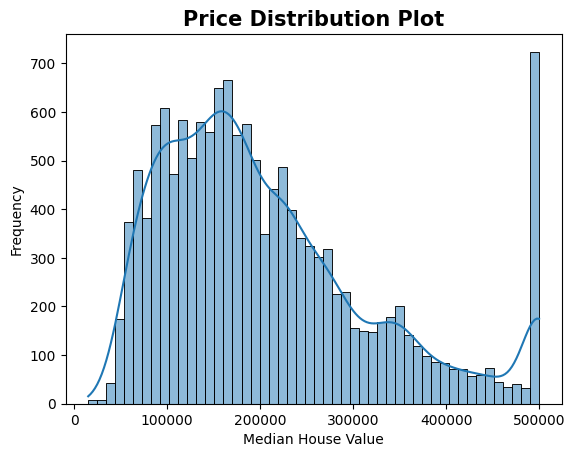

In [1061]:
# Plot distribusi fitur 'median_house_value'

sns.histplot(df['median_house_value'], kde=True, bins=50)
plt.title('Price Distribution Plot', size=15, weight='bold')
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()


Berdasarkan plot distribusi pada variabel median_house_value, terlihat bahwa distribusi harga rumah di California cenderung right-skewed atau memiliki skewness positif. Hal ini menunjukkan bahwa sebagian besar rumah memiliki nilai median pada kisaran harga rendah hingga menengah (sekitar di bawah $200.000–$250.000).


Namun, distribusi juga memperlihatkan adanya ekor panjang ke arah kanan, yang mengindikasikan keberadaan sejumlah kecil rumah dengan nilai yang jauh lebih tinggi dibanding mayoritas. Kondisi ini umum terjadi pada data harga rumah karena adanya variasi signifikan antara rumah standar dengan rumah mewah.


Selain itu, terlihat pula adanya lonjakan (spike) pada batas harga $500.000. Hal ini terjadi karena dataset hasil sensus menetapkan batas maksimum (capping) pada nilai rumah, sehingga semua rumah dengan harga lebih tinggi dari $500.000 dicatat pada angka tersebut. Akibatnya, distribusi menjadi tidak sepenuhnya alami pada bagian ekor kanan.

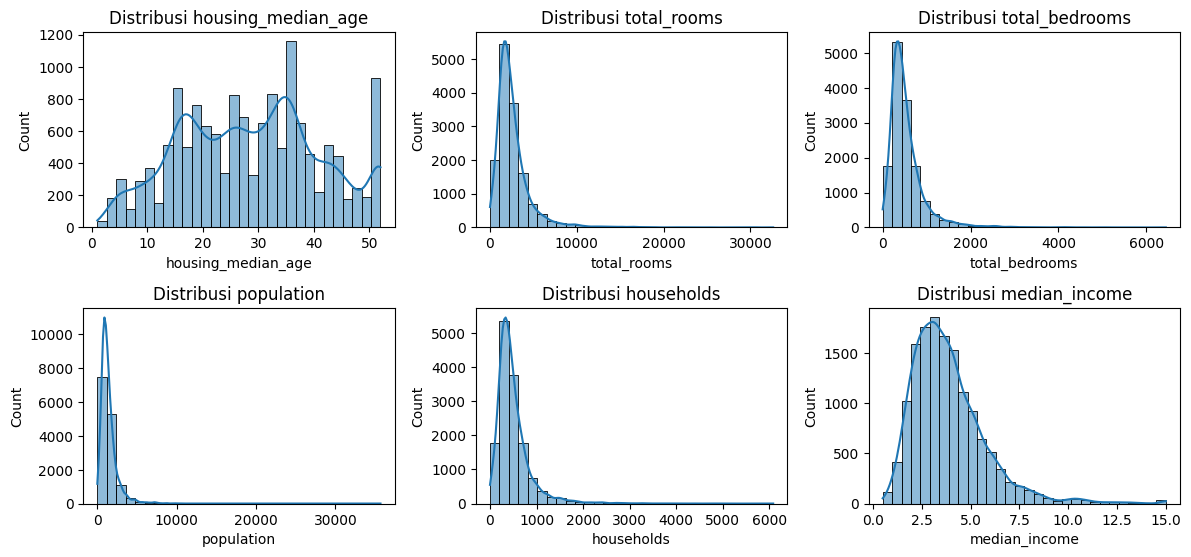

In [1062]:
# Plot distribusi fitur 'median_house_value'

numeric_cols = ["housing_median_age","total_rooms","total_bedrooms",
                "population","households","median_income"]

plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

Dari histogram diatas, bisa disimpulkan bahwa :

housing_median_age = Histogram menunjukkan distribusi yang cukup merata dengan konsentrasi tinggi di usia 20–30 tahun. Terlihat ada batas maksimum di angka 52, sehingga data berhenti di titik tersebut.

total_rooms = Distribusi sangat miring ke kanan (right-skewed). Mayoritas distrik memiliki jumlah kamar rendah, sementara beberapa outlier memiliki jumlah kamar yang jauh lebih tinggi dibanding mayoritas.

total_bedrooms = Bentuk distribusinya mirip dengan total_rooms, skewed ke kanan. Sebagian besar distrik hanya memiliki sedikit kamar tidur, tetapi ada beberapa yang jumlahnya jauh lebih banyak.

population = Histogram populasi juga menunjukkan distribusi miring ke kanan. Kebanyakan distrik berpenduduk rendah, sedangkan hanya sedikit distrik yang populasinya sangat tinggi.

households = Distribusi jumlah rumah tangga sangat mirip dengan populasi, right-skewed. Sebagian besar distrik memiliki jumlah rumah tangga kecil, dengan sedikit distrik yang memiliki jumlah besar.

median_income = Histogram median_income tampak lebih terpusat dengan puncak di kisaran 2–5. Distribusinya tidak terlalu ekstrem seperti variabel lain, meskipun ada sedikit data di bagian kanan yang lebih tinggi.

**Types of property related to Median House Value**

In [1063]:
# Cek jumlah properti berdasarkan ocean_proximity
print(f"Jumlah properti di tiap lokasi (ocean_proximity):\n{df['ocean_proximity'].value_counts()}")

Jumlah properti di tiap lokasi (ocean_proximity):
ocean_proximity
<1H OCEAN     6369
INLAND        4576
NEAR OCEAN    1879
NEAR BAY      1622
ISLAND           2
Name: count, dtype: int64


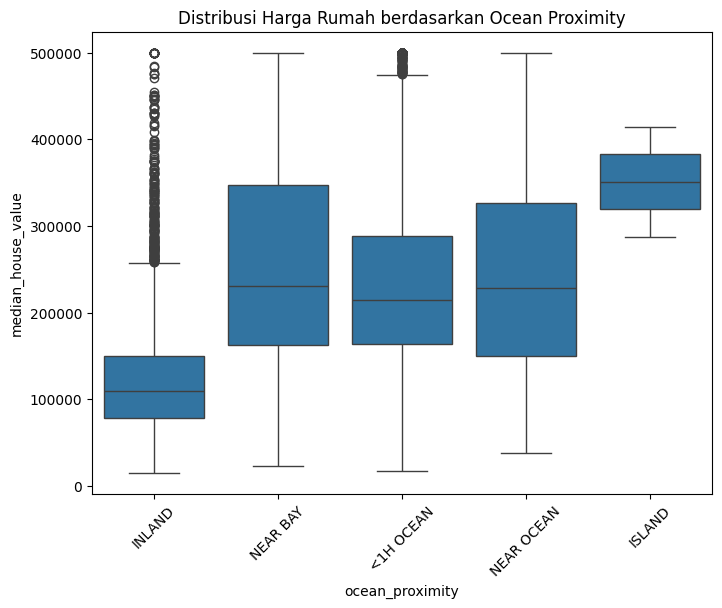

In [1064]:
# Distribusi Harga Rumah berdasarkan Ocean Proximity

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value")
plt.title("Distribusi Harga Rumah berdasarkan Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

Boxplot menunjukkan bahwa harga rumah bervariasi cukup signifikan berdasarkan kedekatan dengan laut. Rumah di area **INLAND** cenderung memiliki harga paling rendah dengan banyak outlier di atasnya, menandakan ada beberapa rumah mahal namun mayoritas harganya relatif rendah. Kategori **NEAR BAY** dan **NEAR OCEAN** memiliki rentang harga yang lebih lebar dengan median lebih tinggi dibanding INLAND. Sementara itu, **<1H OCEAN** memiliki median harga yang mirip dengan NEAR OCEAN tetapi dengan sebaran yang lebih terkonsentrasi. Yang paling mencolok adalah kategori **ISLAND**, di mana median harga rumah jauh lebih tinggi dibanding kategori lain, serta variasinya lebih sempit sehingga menunjukkan konsistensi harga tinggi di area ini. **Kesimpulannya**, semakin dekat dan eksklusif lokasi rumah terhadap laut, terutama di area pulau, semakin tinggi pula nilai median harga rumahnya.

In [1065]:
# Median house value untuk tiap lokasi

df_median_value = df.groupby(by=['ocean_proximity']).agg({'median_house_value':'median'}).reset_index()
df_median_value = df_median_value.set_index('ocean_proximity')
df_median_value = df_median_value.sort_values('median_house_value', ascending=False)
print(df_median_value)

                 median_house_value
ocean_proximity                    
ISLAND                     351100.0
NEAR BAY                   230800.0
NEAR OCEAN                 228600.0
<1H OCEAN                  214800.0
INLAND                     108800.0


In [1067]:
# Median Income berdasarkan Ocean Proximity

income_mean = (
    df.groupby("ocean_proximity")["median_income"]
      .mean()
      .reset_index()
      .sort_values(by="median_income", ascending=False)
)
print(income_mean)


  ocean_proximity  median_income
0       <1H OCEAN       4.224854
3        NEAR BAY       4.179790
4      NEAR OCEAN       4.014166
1          INLAND       3.197080
2          ISLAND       2.718750


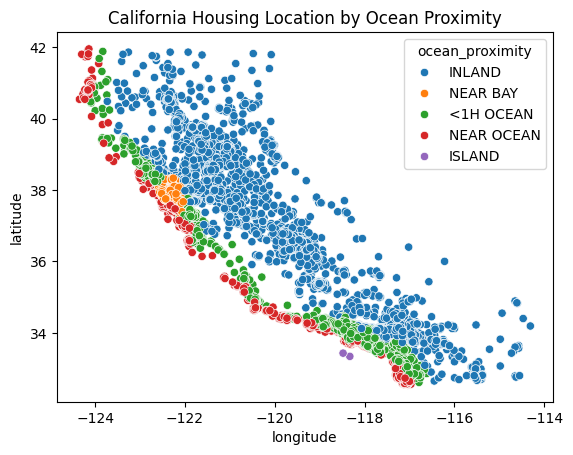

In [1068]:
# Location scatterplot

sns.scatterplot(x=df['longitude'], y=df['latitude'], hue=df['ocean_proximity'])
plt.title('California Housing Location by Ocean Proximity')
plt.show()

Dari scatterplot di atas terlihat bahwa distribusi lokasi rumah di California sangat dipengaruhi oleh kedekatannya dengan laut. Kategori **INLAND** mendominasi data, ditunjukkan oleh sebaran titik biru yang sangat banyak di bagian tengah dan timur California. Kategori **NEAR BAY** dan **NEAR OCEAN** cenderung terkonsentrasi di pesisir barat, terutama sekitar San Francisco Bay dan wilayah pantai Pasifik. Sementara itu, kategori **<1H OCEAN** tersebar di daerah yang tidak langsung berada di pantai, tetapi masih dalam jarak tempuh sekitar satu jam dari laut. Adapun kategori **ISLAND** sangat jarang, terlihat hanya beberapa titik saja.
Kesimpulannya, sebagian besar perumahan di California berada di wilayah daratan jauh dari laut (INLAND), sementara rumah dengan kedekatan laut relatif lebih sedikit tetapi berpotensi memiliki nilai harga yang lebih tinggi karena faktor lokasi premium di sekitar pesisir. Ini menunjukkan bahwa lokasi geografis, khususnya kedekatan dengan laut, merupakan faktor penting dalam distribusi dan potensi harga rumah di California.

### **Data Preprocessing**

Pada tahap ini, kita akan melakukan cleaning pada data yang nantinya data yang sudah dibersihkan akan kita gunakan untuk proses analisis selanjutnya. Beberapa hal yang perlu dilakukan adalah:
- Drop fitur yang tidak memiliki relevansi terhadap permasalahan yang sedang dihadapi.
- Melakukan treatment terhadap missing value jika ada. Bisa dengan cara men-drop fiturnya jika memang tidak dibutuhkan atau bisa juga dengan mengimputasi dengan nilai yang paling masuk akal berdasarkan kasusnya.

Untuk proses data preprocessing dan feature engineering, kita akan menggunakan dataframe hasil duplikasi dari dataframe yang sebelumnya digunakan.

In [1069]:
# Membuat duplikasi dataframe (untuk cleaning processing)

df_model = df.copy()
df_model

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0
...,...,...,...,...,...,...,...,...,...,...
14443,-121.26,38.27,20.0,1314.0,229.0,712.0,219.0,4.4125,INLAND,144600.0
14444,-120.89,37.48,27.0,1118.0,195.0,647.0,209.0,2.9135,INLAND,159400.0
14445,-121.90,36.58,31.0,1431.0,NaN,704.0,393.0,3.1977,NEAR OCEAN,289300.0
14446,-117.93,33.62,34.0,2125.0,498.0,1052.0,468.0,5.6315,<1H OCEAN,484600.0


In [1070]:
# Cek info lebih detail untuk setiap fitur

listItem = []

for col in df_model.columns:
    listItem.append([col, df_model[col].dtype, df_model[col].isna().sum(), round((df_model[col].isna().sum()/len(df_model[col]))*100, 2),
                    df_model[col].nunique(), list(df_model[col].drop_duplicates().sample(2).values)]);

df_model_desc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)

df_model_desc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,longitude,float64,0,0.00,806,"[-116.44, -119.17]"
1,latitude,float64,0,0.00,836,"[38.94, 37.3]"
2,housing_median_age,float64,0,0.00,52,"[49.0, 10.0]"
3,total_rooms,float64,0,0.00,5227,"[4213.0, 3453.0]"
4,total_bedrooms,float64,137,0.95,1748,"[1252.0, 1059.0]"
5,population,float64,0,0.00,3498,"[2634.0, 566.0]"
6,households,float64,0,0.00,1649,"[1033.0, 1593.0]"
7,median_income,float64,0,0.00,9797,"[3.0217, 4.5828]"
8,ocean_proximity,object,0,0.00,5,"[<1H OCEAN, NEAR BAY]"
9,median_house_value,float64,0,0.00,3548,"[145600.0, 352700.0]"


Dari info dataset di atas, terdapat data yang kosong pada beberapa fitur atau kolom. Selanjutnya, kita perlu mengobservasi lebih lanjut terkait data-data yang hilang tersebut agar dapat menentukan langkah treatment yang tepat untuk mengatasinya.

In [1071]:
# Cek nilai missing value

df_model.isna().sum()/len(df_model)*100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.948228
population            0.000000
households            0.000000
median_income         0.000000
ocean_proximity       0.000000
median_house_value    0.000000
dtype: float64

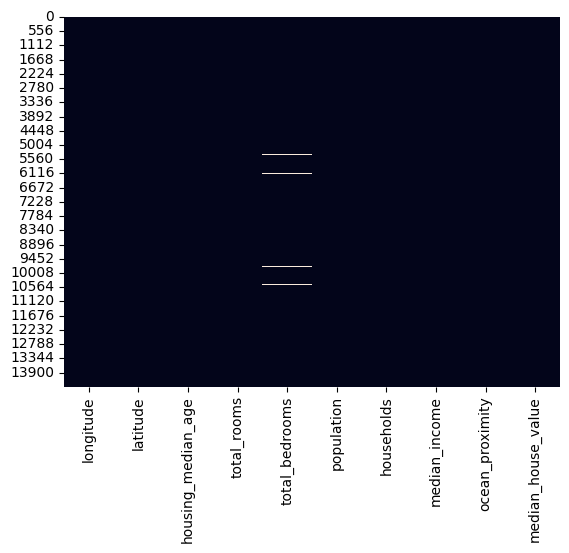

In [1072]:
# Missing value heatmap

sns.heatmap(df_model.isnull(), cbar=False);

Terdapat 1 fitur yang memiliki missing value. Fitur **total_bedrooms** memiliki sebanyak 137 missing value dan persentasenya hanya 0.94% dari total data. Dan sudah dipastikan missing value tersebut akan dihapus.

In [1073]:
# Drop Missing Value (total_bedrooms - 0.948%)

df_model.dropna(inplace=True)

In [1074]:
# Check data setelah drop missing value

df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14311 entries, 0 to 14447
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14311 non-null  float64
 1   latitude            14311 non-null  float64
 2   housing_median_age  14311 non-null  float64
 3   total_rooms         14311 non-null  float64
 4   total_bedrooms      14311 non-null  float64
 5   population          14311 non-null  float64
 6   households          14311 non-null  float64
 7   median_income       14311 non-null  float64
 8   ocean_proximity     14311 non-null  object 
 9   median_house_value  14311 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.2+ MB


In [1075]:
# Cek deskriptif statistik fitur numerikal

num_features = [feature for feature in df_model.columns if ((df_model[feature].dtypes != 'object'))]
df_model[num_features].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,14311.000000,14311.000000,14311.000000,14311.000000,14311.000000,14311.000000,14311.000000,14311.000000,14311.000000
mean,-119.567150,35.631365,28.609671,2640.917686,538.260709,1424.772273,499.480470,3.866774,206793.156942
std,2.006374,2.139589,12.606493,2197.192896,423.577544,1151.795857,383.826005,1.890866,115404.371629
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1452.000000,295.000000,784.000000,279.000000,2.569400,119400.000000
50%,-118.490000,34.260000,29.000000,2125.000000,435.000000,1164.000000,410.000000,3.540300,180000.000000
75%,-118.000000,37.715000,37.000000,3142.000000,647.000000,1722.000000,603.500000,4.736100,263750.000000
max,-114.310000,41.950000,52.000000,32627.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [1076]:
# Cek data duplikat

df_model.duplicated().sum()

np.int64(0)

Feature **latitude** dan **longitude** merupakan data koordinat mentah yang menunjukkan lokasi geografis setiap distrik. Namun, informasi ini sulit untuk langsung diinterpretasikan karena tidak memberikan makna yang jelas tanpa dilakukan pengolahan lebih lanjut, misalnya dengan memetakannya ke dalam wilayah administrasi tertentu, mengelompokkan ke dalam cluster, atau menghitung jarak ke titik penting (seperti pusat kota atau garis pantai). Tanpa transformasi tersebut, kedua feature ini cenderung tidak memberikan kontribusi yang signifikan terhadap model prediksi dan justru berpotensi menambah kompleksitas yang tidak perlu. Oleh karena itu, kolom latitude dan longitude diputuskan untuk dihapus dari analisis.

In [1077]:
# Hapus Feature 'Latitude' dan 'Longitude'

df_model.drop(['latitude','longitude'],axis=1,inplace=True)
df_model

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0
...,...,...,...,...,...,...,...,...
14442,19.0,901.0,183.0,700.0,190.0,2.2375,INLAND,64300.0
14443,20.0,1314.0,229.0,712.0,219.0,4.4125,INLAND,144600.0
14444,27.0,1118.0,195.0,647.0,209.0,2.9135,INLAND,159400.0
14446,34.0,2125.0,498.0,1052.0,468.0,5.6315,<1H OCEAN,484600.0


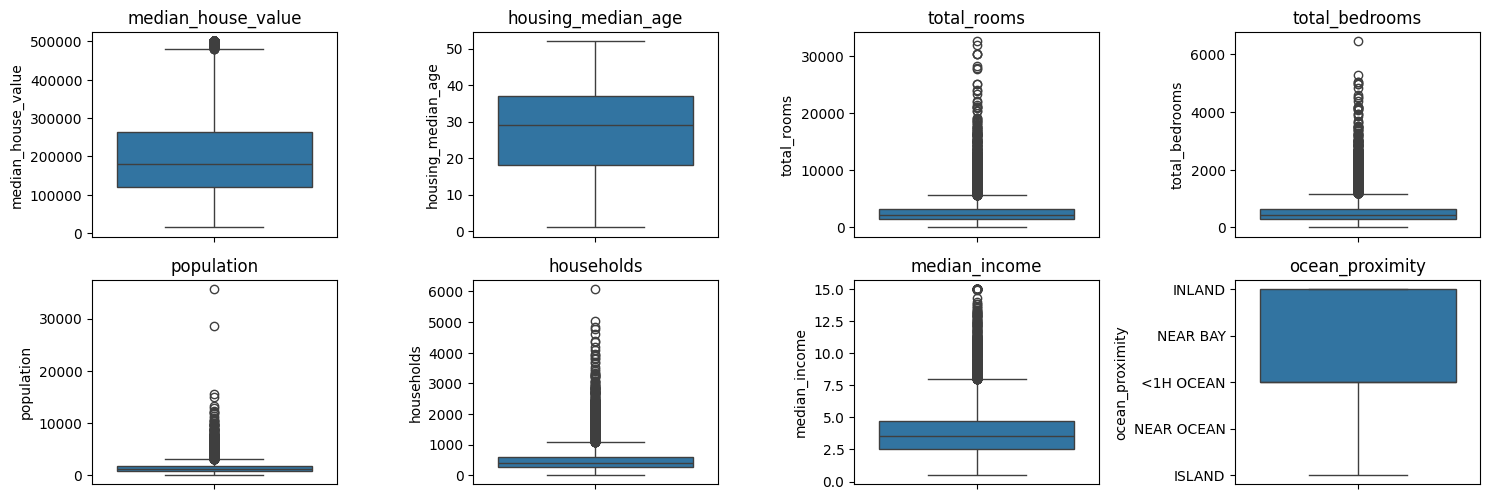

In [1078]:
# Boxplot untuk cek Outlier

# list variabel X numerik
num_vars = ['median_house_value','housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_vars, 1):
    plt.subplot(4, 4, i)  # bikin grid 4x4
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Dari Boxplot diatas bisa disimpulkan, bahwa:
- median_house_value = Ada outlier mendekati 500k, merepresentasikan rumah mahal di California. Kesimpulan: wajar, sebaiknya tetap dipertahankan.
- housing_median_age = Ada beberapa outlier di atas 50 tahun, menunjukkan bangunan tua. Kesimpulan: wajar dan tetap bisa dipakai.
- total_rooms = Banyak outlier dengan nilai ribuan hingga puluhan ribu kamar. Kesimpulan: hanya menghapus extreme outlier saja.
- total_bedrooms = Banyak outlier dengan ribuan kamar tidur. Kesimpulan: hanya menghapus extreme outlier saja.
- population = Outlier sangat banyak, populasi bisa sampai puluhan ribu. Kesimpulan: hanya menghapus extreme outlier saja.
- households = Outlier banyak dengan ribuan rumah tangga. Kesimpulan: hanya menghapus extreme outlier saja.
- median_income = Ada outlier di bagian atas (>12), merepresentasikan area dengan pendapatan tinggi. Kesimpulan: wajar, tetap dipertahankan kecuali analisis ingin fokus ke mayoritas.
- ocean_proximity = Data kategorikal, tidak ada outlier. Kesimpulan: aman.

In [1079]:

# Check detail outliers

def find_anomalies(df_model, column):
    q1 = df_model[column].quantile(0.25)
    q3 = df_model[column].quantile(0.75)
    iqr = q3 - q1
    limit = iqr * 1.5

    limit_bawah = q1 - limit
    limit_atas = q3 + limit

    print(f'[{column}]')
    print(f'Q1: {q1:.2f}')
    print(f'Q3: {q3:.2f}')
    print(f'IQR: {iqr:.2f}')
    print(f'Lower Bound: {limit_bawah:.2f}')
    print(f'Upper Bound: {limit_atas:.2f}')

    # Hitung jumlah outliers
    num_outliers = df_model[(df_model[column] < limit_bawah) | (df_model[column] > limit_atas)].shape[0]
    print(f'Jumlah outlier: {num_outliers}')
    print('-' * 40)

cols = ['total_rooms', 'total_bedrooms', 'population', 'households']

for col in cols:
    find_anomalies(df_model, col)


[total_rooms]
Q1: 1452.00
Q3: 3142.00
IQR: 1690.00
Lower Bound: -1083.00
Upper Bound: 5677.00
Jumlah outlier: 905
----------------------------------------
[total_bedrooms]
Q1: 295.00
Q3: 647.00
IQR: 352.00
Lower Bound: -233.00
Upper Bound: 1175.00
Jumlah outlier: 879
----------------------------------------
[population]
Q1: 784.00
Q3: 1722.00
IQR: 938.00
Lower Bound: -623.00
Upper Bound: 3129.00
Jumlah outlier: 822
----------------------------------------
[households]
Q1: 279.00
Q3: 603.50
IQR: 324.50
Lower Bound: -207.75
Upper Bound: 1090.25
Jumlah outlier: 836
----------------------------------------


In [1080]:
# Menghapus Extreme Outlier untuk 'total_rooms','total_bedrooms','population' dan 'households'

# Batas atas dari hasil find_anomalies
upper_bounds = {
    'total_rooms': 5693.5,
    'total_bedrooms': 1175.0,
    'population': 3134.0,
    'households': 1091.5
}

# Hapus outlier
for col, upper in upper_bounds.items():
    df_model = df_model[df_model[col] <= upper]

print("Jumlah data setelah hapus outlier ekstrem:", df_model.shape)


Jumlah data setelah hapus outlier ekstrem: (13040, 8)


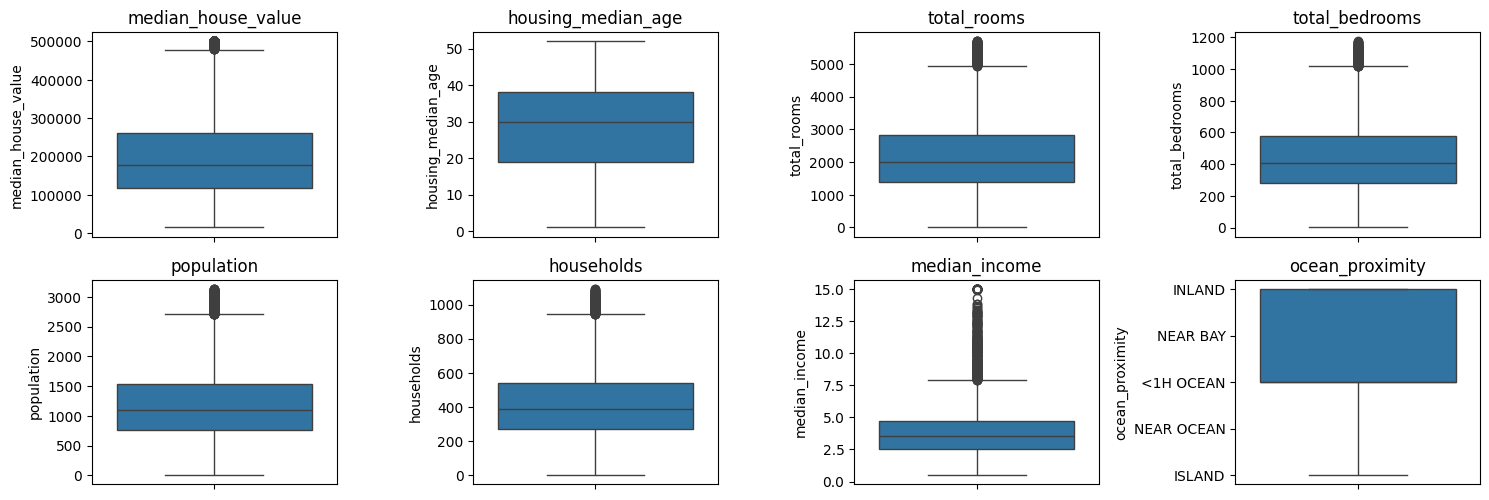

In [1081]:
# Boxplot untuk cek Outlier After Take out

# list variabel X numerik
num_vars = ['median_house_value','housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_vars, 1):
    plt.subplot(4, 4, i)  # bikin grid 4x4
    sns.boxplot(y=df_model[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Cek Korelasi X terhadap Y**

In [1082]:
# Data Numeric
corr = df_model.corr(numeric_only=True)
corr_target = corr['median_house_value'].sort_values(ascending=False)

print(corr_target)

median_house_value    1.000000
median_income         0.693262
total_rooms           0.175714
housing_median_age    0.119768
households            0.057278
total_bedrooms        0.035891
population           -0.081551
Name: median_house_value, dtype: float64


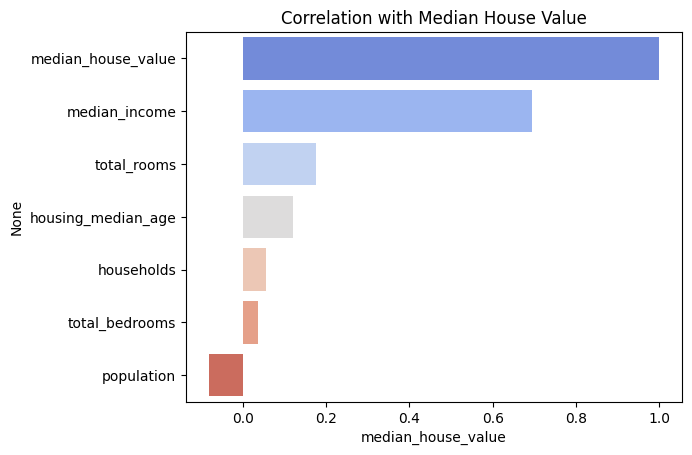

In [1083]:
# Visualisasi

sns.barplot(x=corr_target, y=corr_target.index, palette="coolwarm")
plt.title("Correlation with Median House Value")
plt.show()

Grafik ini menunjukkan nilai korelasi antara berbagai variabel dengan **median_house_value** (nilai median rumah). **median_income** memiliki korelasi paling tinggi dengan nilai rumah (sekitar 0.69), menunjukkan hubungan positif yang kuat. Variabel lain seperti **total_rooms, housing_median_age, households, total_bedrooms**, dan population memiliki korelasi yang jauh lebih rendah. Korelasi tertinggi setelah **median_house_value** (1.0) adalah **median_income**, yang terlihat dari panjang batang ungu yang signifikan.

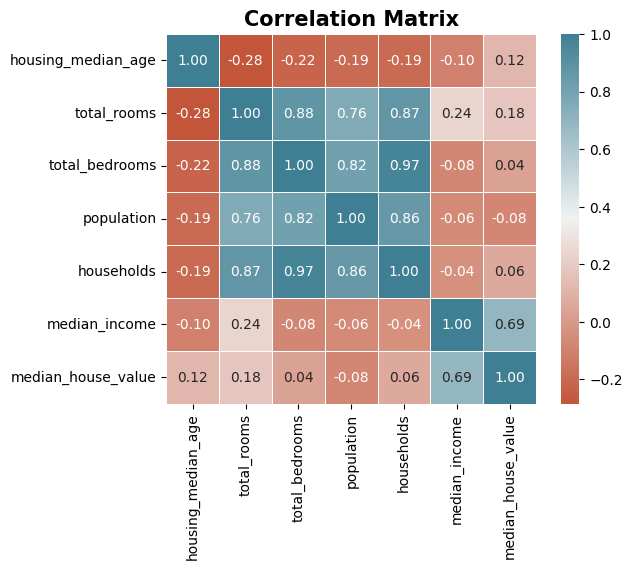

In [1084]:
# Correlation matrix

palette = sns.diverging_palette(20, 220, n=256)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=palette, square=True, linewidths=.5)
plt.title('Correlation Matrix', size=15, weight='bold')
plt.show()


Ini adalah matriks korelasi antara semua variabel dalam dataset. Warna hijau menunjukkan korelasi positif, sedangkan warna oranye menunjukkan korelasi negatif. Diagonal utama berisi nilai 1 karena setiap variabel berkorelasi sempurna dengan dirinya sendiri. Korelasi antara **median_income** dan **median_house_value** adalah 0.69, nilai tertinggi di antara semua kombinasi. Banyak variabel seperti **total_rooms, total_bedrooms, population**, dan **households** memiliki korelasi tinggi antar satu sama lain, namun tidak kuat terhadap **median_house_value**. Terdapat multikolinearitas antar beberapa variabel (misalnya **total_rooms** dan **total_bedrooms**: 0.93). Namun, hanya **median_income** yang punya hubungan cukup kuat terhadap harga rumah.

**Clean Dataset**

In [1085]:
# Cek Dataset yang sudah bersih

display(df_model)
display(df_model.info())

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
4,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0
6,14.0,1206.0,142.0,572.0,149.0,8.8470,<1H OCEAN,388700.0
...,...,...,...,...,...,...,...,...
14442,19.0,901.0,183.0,700.0,190.0,2.2375,INLAND,64300.0
14443,20.0,1314.0,229.0,712.0,219.0,4.4125,INLAND,144600.0
14444,27.0,1118.0,195.0,647.0,209.0,2.9135,INLAND,159400.0
14446,34.0,2125.0,498.0,1052.0,468.0,5.6315,<1H OCEAN,484600.0


<class 'pandas.core.frame.DataFrame'>
Index: 13040 entries, 0 to 14447
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  13040 non-null  float64
 1   total_rooms         13040 non-null  float64
 2   total_bedrooms      13040 non-null  float64
 3   population          13040 non-null  float64
 4   households          13040 non-null  float64
 5   median_income       13040 non-null  float64
 6   ocean_proximity     13040 non-null  object 
 7   median_house_value  13040 non-null  float64
dtypes: float64(7), object(1)
memory usage: 916.9+ KB


None

Pada akhirnya, tersisa 13040 dari 14448 baris data yang akan digunakan untuk pemodelan. Ini berarti 9,75% data sudah tereliminasi sesuai dengan asumsi dan argumen yang disampaikan di proses-proses sebelumnya.

### **Modeling**

Setelah mengerti tentang data, selanjutnya kita akan melakukan modeling

In [1086]:
# Import library 

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingRegressor

Pertama, kita mengimpor beberapa model potensial dari keluarga model regresi yang akan dilatih.

Kita akan menggunakan 9 model awal yang berbeda untuk dilatih.

**Models brief explanation:**
1. Linear Regression (Regresi Linier):
Regresi linier adalah algoritma regresi dasar yang banyak digunakan. Model ini memodelkan hubungan antara variabel dependen dan satu atau lebih variabel independen dalam bentuk persamaan linier. Cocok digunakan jika terdapat hubungan linier antar variabel.

2. K-Nearest Neighbors (KNN) Regressor:
KNN regressor memprediksi nilai suatu titik data dengan menghitung rata-rata dari nilai k tetangga terdekatnya. Model ini berguna ketika data memiliki pola lokal dan nilai prediksi diharapkan mirip dengan titik-titik di sekitarnya.

3. Decision Tree Regressor (Regresi Pohon Keputusan):
Model ini membentuk struktur pohon untuk memprediksi variabel target berdasarkan serangkaian keputusan biner. Cocok untuk hubungan linier maupun non-linier, serta dapat menangani fitur numerik maupun kategorikal.

4. Support Vector Regression (SVR):
SVR menggunakan metode Support Vector Machine untuk tugas regresi. Model ini mencari hyperplane yang memaksimalkan margin dan meminimalkan galat antara nilai prediksi dan nilai aktual. Cocok untuk hubungan kompleks dan data non-linier.

5. Random Forest Regressor:
Random forest adalah metode ensemble learning yang menggabungkan beberapa pohon keputusan untuk membuat prediksi. Model ini tangguh terhadap overfitting dan bekerja dengan baik pada dataset kompleks, baik numerik maupun kategorikal.

6. XGBoost Regressor:
XGBoost adalah implementasi dari metode gradient boosting, yang membangun kumpulan model prediksi lemah menjadi model prediksi kuat. Sangat unggul dalam menangani dataset besar dan kompleks, serta memiliki akurasi prediksi yang tinggi.

7. Ridge Regression:
Ridge regression adalah model regresi linier yang dilengkapi dengan regularisasi, dengan menambahkan penalti pada fungsi loss. Ini membantu mengurangi dampak multikolinearitas dalam data. Cocok untuk data berdimensi tinggi dan fitur-fitur yang saling berkorelasi.

8. Lasso Regression:
Lasso regression juga merupakan model regresi linier yang dilengkapi regularisasi, tetapi dengan penalti L1. Model ini juga melakukan seleksi variabel, sangat berguna jika terdapat banyak fitur namun hanya sebagian kecil yang berpengaruh terhadap variabel target.

9. Gradient Boosting Regressor:
Gradient boosting adalah metode ensemble yang menggabungkan banyak model lemah secara berurutan untuk meningkatkan performa prediksi. Efektif untuk berbagai macam permasalahan regresi, dengan akurasi tinggi dan mampu menangani hubungan kompleks antar variabel.

Kita juga mengimpor tools untuk melakukan preprocessing data dan membuat sebuah transformer untuk membedakan proses atau alat yang digunakan pada setiap kolom. Dalam tahap preprocessing ini, kita hanya menggunakan **One Hot Encoder** untuk kolom kategorikal **(ocean_proximity)**, karena sebagian besar data sudah cukup bersih dan tidak memerlukan banyak pembersihan tambahan.
Sedangkan, Kolom **housing_median_age, total_rooms, total_bedrooms, population, households, dan median_income** merupakan kolom numerik yang akan diproses menggunakan **StandardScaler**.

1. StandardScaler():
StandardScaler adalah metode untuk menstandarkan data numerik dengan cara mengurangi nilai rata-rata (mean) dan membaginya dengan standar deviasi. Hasilnya adalah data yang memiliki rata-rata 0 dan standar deviasi 1.
Standardisasi ini penting karena banyak algoritma machine learning, seperti regresi linier, KNN, dan SVM, sensitif terhadap skala fitur. Jika data numerik memiliki skala yang sangat berbeda, maka fitur dengan nilai besar bisa mendominasi proses pelatihan dan membuat model tidak akurat. Dengan StandardScaler, semua fitur numerik memiliki skala yang seimbang, sehingga algoritma bisa belajar secara adil dari semua fitur.

2. OneHotEncoder():
OneHotEncoder mengubah fitur kategorikal menjadi format biner, yaitu dengan membuat kolom terpisah untuk setiap kategori yang ada dan mengisinya dengan nilai 0 atau 1. Ini berguna ketika fitur kategorikal tidak memiliki urutan atau tingkatan tertentu, sehingga representasi numerik biasa (seperti label encoding) bisa menyesatkan model.

3. ColumnTransformer():
ColumnTransformer memungkinkan kita menerapkan transformasi yang berbeda pada kolom yang berbeda dalam satu langkah. Misalnya, kita bisa menggunakan StandardScaler untuk kolom numerik dan OneHotEncoder untuk kolom kategorikal secara bersamaan. Ini sangat efisien saat bekerja dengan dataset yang memiliki berbagai tipe data, karena memudahkan pipeline pemrosesan data secara otomatis dan terstruktur.

In [1087]:
linreg = LinearRegression()
knnreg = KNeighborsRegressor()
treereg = DecisionTreeRegressor()
svreg = SVR()
rfreg = RandomForestRegressor()
xgbreg = XGBRegressor()
ridgereg = Ridge()
lassoreg = Lasso()
gradientreg = GradientBoostingRegressor()
normalModel = [linreg,knnreg,treereg,svreg,rfreg,xgbreg,ridgereg,lassoreg,gradientreg]
normalModelName = ['linreg','knnreg','treereg','svreg','rfreg','xgbreg','ridgereg','lassoreg','gradientreg']

**Encoding**

Agar dapat menggunakan semua fitur yang dipilih, maka fitur-fitur kategorikal harus diubah menjadi fitur numerikal. Kita dapat menggunakan **ColumnTransformer** untuk dapat mengubah tipe datanya, yang mana nanti dapat diaplikasikan pada pipeline model.

In [1088]:
# Import Encoding library
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [1089]:
# Mengubah fitur kategorikal menjadi numerikal

encoderOHE = OneHotEncoder()
transformer = ColumnTransformer([('encodingOHE',encoderOHE,['ocean_proximity'])],
                                remainder='passthrough')
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('encodingOHE', OneHotEncoder(),
                                 ['ocean_proximity'])])

**Data Splitting**

Data splitting adalah proses membagi dataset menjadi beberapa bagian untuk keperluan pelatihan dan pengujian model. Tujuannya agar model dapat diuji pada data yang belum pernah dilihat, sehingga hasil evaluasi lebih objektif dan model tidak overfitting.

In [1090]:
x = df_model.drop('median_house_value',axis=1)
y = df_model['median_house_value']

**Train and Test Data Split**

Train and test data split adalah metode membagi data menjadi dua bagian: data latih dan data uji. Data latih digunakan untuk membangun model, sedangkan data uji digunakan untuk mengukur performa model. Untuk Train and Test disini pembagian dilakukan dengan rasio 80:20.

In [1091]:
from sklearn.model_selection import train_test_split

In [1092]:
# Splitting data training dan test dengan proporsi 80:20

xTrain, xTest, yTrain, yTest = train_test_split(x,
                                                 y,
                                                 random_state = 99,
                                                 test_size = 0.2)
display(df_model,
        xTrain,
        xTest,
        yTrain,
        yTest)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
4,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0
6,14.0,1206.0,142.0,572.0,149.0,8.8470,<1H OCEAN,388700.0
...,...,...,...,...,...,...,...,...
14442,19.0,901.0,183.0,700.0,190.0,2.2375,INLAND,64300.0
14443,20.0,1314.0,229.0,712.0,219.0,4.4125,INLAND,144600.0
14444,27.0,1118.0,195.0,647.0,209.0,2.9135,INLAND,159400.0
14446,34.0,2125.0,498.0,1052.0,468.0,5.6315,<1H OCEAN,484600.0


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13512,45.0,3723.0,831.0,2256.0,770.0,1.8299,INLAND
12157,23.0,2296.0,356.0,902.0,334.0,6.0298,<1H OCEAN
14368,32.0,1893.0,431.0,2245.0,426.0,3.7143,<1H OCEAN
14196,29.0,1733.0,255.0,679.0,278.0,7.5337,<1H OCEAN
8171,16.0,3077.0,465.0,1575.0,446.0,5.5000,INLAND
...,...,...,...,...,...,...,...
1948,13.0,2085.0,292.0,852.0,264.0,7.3445,INLAND
10987,15.0,3991.0,751.0,2317.0,657.0,2.9542,INLAND
3568,33.0,2581.0,623.0,1598.0,628.0,3.5199,<1H OCEAN
7965,5.0,1395.0,373.0,638.0,322.0,2.6745,INLAND


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
7012,18.0,1819.0,283.0,919.0,295.0,4.1696,<1H OCEAN
1681,26.0,4151.0,823.0,2822.0,697.0,2.8372,NEAR OCEAN
7905,29.0,1813.0,501.0,1170.0,482.0,2.0677,<1H OCEAN
12622,13.0,2171.0,339.0,951.0,353.0,4.8516,NEAR OCEAN
1943,17.0,2772.0,576.0,1501.0,584.0,2.6275,<1H OCEAN
...,...,...,...,...,...,...,...
13206,24.0,1194.0,246.0,414.0,151.0,3.2396,INLAND
12815,26.0,1317.0,374.0,1025.0,304.0,1.4024,INLAND
3151,35.0,1942.0,332.0,1127.0,325.0,4.5144,<1H OCEAN
5777,32.0,4474.0,929.0,2177.0,884.0,3.2889,INLAND


13512     63100.0
12157    289100.0
14368    163000.0
14196    406800.0
8171     179500.0
           ...   
1948     366700.0
10987    127900.0
3568     261400.0
7965     225000.0
14323    107500.0
Name: median_house_value, Length: 10432, dtype: float64

7012     222500.0
1681     123400.0
7905     214500.0
12622    116100.0
1943     142100.0
           ...   
13206    101900.0
12815     51000.0
3151     206300.0
5777      98900.0
8179     165400.0
Name: median_house_value, Length: 2608, dtype: float64

Pertama, kita melakukan pembagian data (train-test split) dari dataset utama.
Dengan pembagian ini, kita akan memiliki dua dataset berbeda yang digunakan untuk tujuan berbeda: pelatihan (training) dan pengujian/validasi (testing/validating).
Proporsi pembagiannya adalah 80% untuk data latih dan 20% untuk data uji.

Train-test split dilakukan sebelum proses pemodelan untuk menilai sejauh mana model dapat menggeneralisasi ke data yang belum pernah dilihat sebelumnya. Dengan membagi dataset menjadi data latih dan data uji, model dilatih menggunakan data latih dan dievaluasi menggunakan data uji. Ini membantu memperkirakan performa model terhadap data baru serta mendeteksi masalah overfitting. Selain itu, pembagian ini juga memungkinkan untuk melakukan penyesuaian hyperparameter dan membandingkan performa berbagai model secara objektif, sehingga mendukung proses pemilihan model yang terbaik dan menghindari evaluasi yang bias.

In [1093]:
# Data Desc
listItem = []
for col in x.columns :
    listItem.append([col,
                     x[col].dtype,
                     x[col].isna().sum(),
                     round(((x[col].isna().sum()) / (len(x))) * 100 , 2),
                     x[col].nunique(),
                     list(x[col].drop_duplicates().sample(5,replace=True).values)])
    
descData = pd.DataFrame(data= listItem,
                        columns = ['column',
                                   'Data Type',
                                   'Missing Values',
                                   'Pct Missing Values',
                                   'Num Unique',
                                   'Unique Sample'])

display(descData.merge(x.describe().transpose().reset_index().rename({'index' : 'column'},axis=1),
                       'left',
                       'column'))

,column,Data Type,Missing Values,Pct Missing Values,Num Unique,Unique Sample,count,mean,std,min,25%,50%,75%,max
0,housing_median_age,float64,0,0.0,52,"[7.0, 39.0, 26.0, 50.0, 20.0]",13040.0,29.673466,12.333168,1.0000,19.000000,30.0000,38.0,52.0000
1,total_rooms,float64,0,0.0,4255,"[1107.0, 2391.0, 28.0, 3009.0, 454.0]",13040.0,2165.971396,1102.259759,2.0000,1391.000000,1999.0000,2813.0,5688.0000
2,total_bedrooms,float64,0,0.0,1104,"[222.0, 1056.0, 176.0, 287.0, 43.0]",13040.0,443.137500,221.900954,1.0000,283.000000,410.0000,577.0,1175.0000
3,population,float64,0,0.0,2646,"[1915.0, 1421.0, 1572.0, 708.0, 2125.0]",13040.0,1180.546626,599.596907,3.0000,754.000000,1092.0000,1537.0,3134.0000
4,households,float64,0,0.0,1038,"[997.0, 1075.0, 340.0, 566.0, 707.0]",13040.0,414.569709,205.451310,1.0000,268.000000,386.0000,539.0,1091.0000
5,median_income,float64,0,0.0,8773,"[4.0815, 4.9803, 1.4097, 3.4896, 6.4209]",13040.0,3.834213,1.886365,0.4999,2.547775,3.5156,4.7,15.0001
6,ocean_proximity,object,0,0.0,5,"[ISLAND, ISLAND, NEAR BAY, <1H OCEAN, NEAR BAY]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Kita melakukan tinjauan singkat terhadap karakteristik data latih.
Langkah ini membantu kita untuk mengingat struktur dan nilai-nilai data jika terjadi kesalahan atau masalah dalam proses selanjutnya.

##### **Model Benchmarking**

In [1094]:
# Import library

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_validate, RandomizedSearchCV, GridSearchCV

from sklearn.preprocessing import StandardScaler

Sekarang, kita perlu melakukan **cross-validation** untuk mencari model terbaik dalam bentuk dasarnya.
Proses ini penting untuk menghemat waktu karena kita sudah bisa mengetahui model mana yang paling baik sebelum melakukan tuning hyperparameter.
Hal ini karena, pada umumnya, model dalam bentuk dasar sudah cukup mewakili performa secara keseluruhan.

Cross-validation dilakukan ketika kita memiliki beberapa model dasar untuk mendapatkan estimasi performa yang lebih kuat. Proses ini membagi data menjadi beberapa subset atau *fold*, di mana setiap *fold* bergilir menjadi data validasi, sementara *fold* lainnya digunakan untuk pelatihan. Dengan cara ini, kita dapat mengevaluasi performa masing-masing model pada berbagai subset data, sehingga mengurangi risiko evaluasi yang bias akibat hanya menggunakan satu kali pembagian train-test. Cross-validation memberikan estimasi yang lebih andal tentang kemampuan generalisasi model dan membantu dalam membandingkan serta memilih model dengan performa terbaik.


In [1095]:
# Scaling data

scaler = StandardScaler()

# kandidat model

listMAEall = []
listMAEmean = []
listMAEstd = []

listMAPEall = []
listMAPEmean = []
listMAPEstd = []

listMSEall = []
listMSEmean = []
listMSEstd = []

listRMSEall = []
listRMSEmean = []
listRMSEstd = []

for model in normalModel :
    pipeModel = Pipeline([('prepro',transformer),
                          ('scaler', scaler),
                          ('modeling', model)])
    cvScore = cross_validate(estimator=pipeModel,
                             X = xTrain,
                             y = yTrain,
                             cv = 5,
                             scoring=['neg_mean_absolute_error',
                                      'neg_mean_absolute_percentage_error',
                                      'neg_mean_squared_error',
                                      'neg_root_mean_squared_error'])
    listMAEall.append(cvScore['test_neg_mean_absolute_error'])
    listMAEmean.append(cvScore['test_neg_mean_absolute_error'].mean())
    listMAEstd.append(cvScore['test_neg_mean_absolute_error'].std())
    listMAPEall.append(cvScore['test_neg_mean_absolute_percentage_error'])
    listMAPEmean.append(cvScore['test_neg_mean_absolute_percentage_error'].mean())
    listMAPEstd.append(cvScore['test_neg_mean_absolute_percentage_error'].std())
    listMSEall.append(cvScore['test_neg_mean_squared_error'])
    listMSEmean.append(cvScore['test_neg_mean_squared_error'].mean())
    listMSEstd.append(cvScore['test_neg_mean_squared_error'].std())
    listRMSEall.append(cvScore['test_neg_root_mean_squared_error'])
    listRMSEmean.append(cvScore['test_neg_root_mean_squared_error'].mean())
    listRMSEstd.append(cvScore['test_neg_root_mean_squared_error'].std())

dfCV = pd.DataFrame()
dfCV['algo'] = normalModelName
dfCV['MAEmean'] = listMAEmean
dfCV['MAEstd'] = listMAEstd
dfCV['MAEall'] = listMAEall
dfCV['MAPEmean'] = listMAPEmean
dfCV['MAPEstd'] = listMAPEstd
dfCV['MAPEall'] = listMAPEall
dfCV['MSEmean'] = listMSEmean
dfCV['MSEstd'] = listMSEstd
dfCV['MSEall'] = listMSEall
dfCV['RMSEmean'] = listRMSEmean
dfCV['RMSEstd'] = listRMSEstd
dfCV['RMSEall'] = listRMSEall
dfCV

,algo,MAEmean,MAEstd,MAEall,MAPEmean,MAPEstd,MAPEall,MSEmean,MSEstd,MSEall,RMSEmean,RMSEstd,RMSEall
0,linreg,-50105.058278,970.080882,"[-49844.59370659368, -50994.876352904685, -486...",-0.290008,0.009831,"[-0.2986188990850051, -0.29927661463907707, -0...",-4.664611e+09,2.529137e+08,"[-4476752470.938559, -4800020496.516997, -4421...",-68273.326113,1834.205368,"[-66908.53810193852, -69282.18022346725, -6649..."
1,knnreg,-46004.451188,1043.958142,"[-44896.79137517969, -47534.51566842358, -4483...",-0.262477,0.009455,"[-0.2655589977038706, -0.2782704758128758, -0....",-4.320214e+09,2.745904e+08,"[-4007281793.9496694, -4634859200.432219, -403...",-65695.172403,2087.686909,"[-63303.0946632917, -68079.80023789889, -63521..."
2,treereg,-59806.728191,1240.883271,"[-57775.371346430285, -60964.59367513177, -593...",-0.340817,0.005591,"[-0.3368518248059924, -0.3495251742990342, -0....",-7.488282e+09,2.682108e+08,"[-7050012483.51701, -7690499654.675132, -73198...",-86520.834906,1558.003554,"[-83964.35245696241, -87695.49392457478, -8555..."
3,svreg,-88614.869310,1665.618138,"[-89532.2997701157, -90828.04018586167, -89089...",-0.535936,0.018232,"[-0.5513579307817923, -0.5600594910620248, -0....",-1.408102e+10,4.626115e+08,"[-14436111586.071083, -14637161142.233799, -14...",-118647.345148,1955.488789,"[-120150.3707279802, -120984.13591142352, -119..."
4,rfreg,-44341.838038,654.320744,"[-43367.86305222808, -45336.11139913752, -4396...",-0.257488,0.006927,"[-0.2626652440022681, -0.26824032544963083, -0...",-3.945356e+09,1.903421e+08,"[-3730076363.66481, -4099282357.656152, -37216...",-62793.736096,1517.375212,"[-61074.35111128738, -64025.63828386369, -6100..."
5,xgbreg,-44898.369840,604.446256,"[-44172.57315562111, -45820.73548304983, -4429...",-0.260858,0.005940,"[-0.2632055096023065, -0.2693787418773936, -0....",-4.065842e+09,1.875474e+08,"[-3833351361.884715, -4234892064.8489513, -388...",-63746.982129,1470.990934,"[-61914.064330204616, -65076.04831924685, -623..."
6,ridgereg,-50105.454819,969.809269,"[-49844.05455375441, -50995.27888328524, -4867...",-0.290007,0.009828,"[-0.29861234439753714, -0.2992768015362736, -0...",-4.664592e+09,2.528385e+08,"[-4476659446.084788, -4800128070.916616, -4420...",-68273.198263,1833.696555,"[-66907.8429340297, -69282.95656881724, -66490..."
7,lassoreg,-50105.139324,970.054794,"[-49844.513183028816, -50994.931673989304, -48...",-0.290007,0.009831,"[-0.29861790813466876, -0.29927643971604767, -...",-4.664609e+09,2.529005e+08,"[-4476737425.623074, -4800037064.841399, -4421...",-68273.314207,1834.115534,"[-66908.4256698891, -69282.2997946907, -66491...."
8,gradientreg,-45425.578574,1044.065955,"[-44493.54116484962, -46900.07485817786, -4408...",-0.262803,0.009856,"[-0.269694769548113, -0.27556622863603775, -0....",-4.033772e+09,2.468854e+08,"[-3795655219.0809464, -4305797814.317964, -378...",-63482.484385,1935.442580,"[-61608.889123899535, -65618.57827108084, -615..."


Berdasarkan hasil evaluasi, model RandomForestRegressor (rfreg) menunjukkan performa terbaik dengan MAE rata-rata sekitar -44.341 dan MAPE rata-rata sekitar -0.257. Meskipun MAPE relatif kecil, nilai MAE dan RMSE masih cukup besar, menunjukkan kesalahan absolut model yang cukup signifikan pada rentang nilai target yang besar.

Nilai MAPE yang kecil ini menunjukkan bahwa model memberikan prediksi yang cukup akurat secara persentase, tetapi nilai kesalahan absolut yang besar kemungkinan disebabkan oleh skala nilai target yang besar. Oleh karena itu, penting untuk mempertimbangkan kedua metrik (MAE dan MAPE) saat mengevaluasi performa model agar gambaran kesalahan menjadi lebih lengkap dan sesuai konteks data.

<Axes: ylabel='median_house_value'>

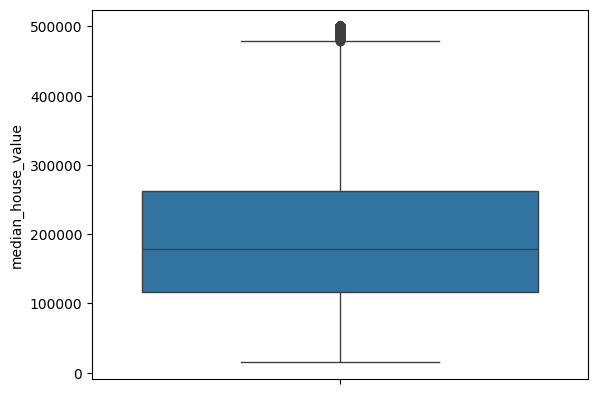

In [1096]:
sns.boxplot(data=df_model,
            y = 'median_house_value')

Dari boxplot di atas, terlihat bahwa variabel **median_house_value** memiliki sebaran data yang tidak merata. Nilai tengah (median) berada di sekitar bagian bawah rentang nilai keseluruhan, menandakan bahwa sebagian besar data memiliki harga rumah menengah ke bawah. Rentang antar kuartil (IQR) yang cukup lebar menunjukkan **adanya variasi harga rumah yang besar di antara wilayah atau sampel yang diamati**. Sementara itu, batas bawah data relatif dekat dengan nol, menunjukkan ada area dengan nilai median rumah yang cukup rendah.

Namun, terlihat juga adanya sejumlah outlier di bagian atas boxplot, dengan nilai yang jauh lebih tinggi dibandingkan mayoritas data. Kehadiran outlier ini menunjukkan bahwa ada wilayah-wilayah tertentu dengan harga rumah yang sangat tinggi, yang dapat memengaruhi rata-rata keseluruhan dan membuat distribusi data menjadi condong ke kanan (right-skewed). Kondisi ini umum terjadi pada data harga rumah karena hanya sebagian kecil area yang memiliki nilai properti jauh di atas rata-rata, misalnya daerah perkotaan atau kawasan premium.

##### **median_house_value with Logarithmic transformer from TransformedTargetRegressor**

In [1097]:
from sklearn.compose import TransformedTargetRegressor

In [1098]:
log_linreg = TransformedTargetRegressor(linreg, func=np.log1p, inverse_func=np.expm1)
log_knnreg = TransformedTargetRegressor(knnreg, func=np.log1p, inverse_func=np.expm1)
log_treereg = TransformedTargetRegressor(treereg, func=np.log1p, inverse_func=np.expm1)
log_rfreg = TransformedTargetRegressor(rfreg, func=np.log1p, inverse_func=np.expm1)
log_svreg = TransformedTargetRegressor(svreg, func=np.log1p, inverse_func=np.expm1)
log_xgbreg = TransformedTargetRegressor(xgbreg, func=np.log1p, inverse_func=np.expm1)
log_ridgereg = TransformedTargetRegressor(ridgereg, func=np.log1p, inverse_func=np.expm1)
log_lassoreg = TransformedTargetRegressor(lassoreg, func=np.log1p, inverse_func=np.expm1)
log_gradientreg = TransformedTargetRegressor(gradientreg, func=np.log1p, inverse_func=np.expm1)
logModel = [log_linreg,log_knnreg,log_treereg,log_svreg,log_rfreg,log_xgbreg,log_ridgereg,log_lassoreg,log_gradientreg]
logModelName = ['log_linreg','log_knnreg','log_treereg','log_svreg','log_rfreg','log_xgbreg','log_ridgereg','log_lassoreg','log_gradientreg']

Kita menggunakan 'func=np.log1p' untuk mentransformasikan variabel **median_house_value** ke dalam skala logarithmic dengan tambahan +1 sebagai koefisien. Tujuannya adalah agar nilai **median_house_value** memiliki sebaran yang lebih merata dan berada pada rentang yang lebih sempit, namun tetap tidak mengandung nilai nol (karena penambahan +1 mencegah log(0)).
Setelah transformasi ini, sebelum proses evaluasi dilakukan, data akan dikembalikan ke skala aslinya menggunakan fungsi kebalikan yaitu 'inverse_func=np.expm1'.

**TransformedTargetRegressor** sendiri merupakan wrapper atau meta-estimator yang memungkinkan kita untuk mentransformasi variabel target sebelum melakukan pelatihan model regresi. Estimator ini akan menerapkan fungsi tertentu (misalnya logaritma atau eksponensial) pada target saat training, dan mengembalikan hasilnya ke skala asli saat melakukan prediksi. Pendekatan ini sangat berguna ketika variabel target memiliki hubungan non-linear atau distribusi yang tidak seimbang (skewed). Dengan menggunakan transformasi ini, diharapkan model dapat menghasilkan prediksi yang lebih stabil dan meningkatkan akurasi MAPE, karena data target sudah berada pada skala yang lebih seragam dan bebas dari nilai nol.

<Axes: ylabel='median_house_value'>

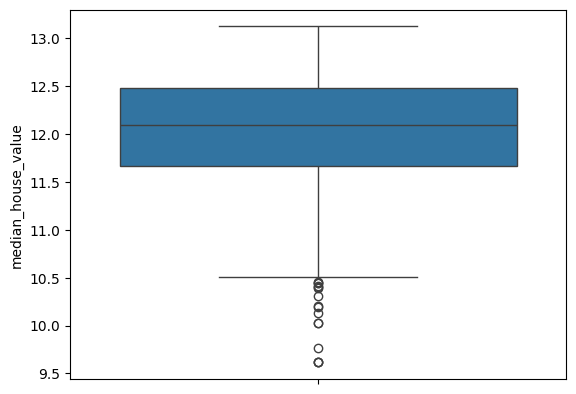

In [1099]:
sns.boxplot(y = np.log1p(df_model['median_house_value']))

Setelah dilakukan **TransformedTargetRegressor** menggunakan **np.log1p**, distribusi variabel **median_house_value** menjadi lebih seimbang dan tidak lagi terlalu condong ke kanan seperti sebelumnya. Nilai median kini berada di tengah rentang data, dan sebaran antar kuartil (IQR) terlihat lebih rapat, menandakan variasi data yang lebih terkendali. Jumlah outlier juga berkurang secara signifikan, hanya tersisa sedikit nilai ekstrem di bagian bawah yang tidak terlalu memengaruhi distribusi keseluruhan. Dengan hasil ini, dapat disimpulkan bahwa transformasi log berhasil menstabilkan skala data dan mengurangi pengaruh outlier, sehingga variabel target menjadi lebih ideal untuk digunakan dalam pemodelan regresi.

In [1100]:
# kandidat model

listMAEall = []
listMAEmean = []
listMAEstd = []

listMAPEall = []
listMAPEmean = []
listMAPEstd = []

listMSEall = []
listMSEmean = []
listMSEstd = []

listRMSEall = []
listRMSEmean = []
listRMSEstd = []

for model in logModel :
    pipeModel = Pipeline([('prepro',transformer),
                          ('scaler', scaler),
                          ('modeling', model)])
    cvScore = cross_validate(estimator=pipeModel,
                             X = xTrain,
                             y = yTrain,
                             cv = 5,
                             scoring=['neg_mean_absolute_error',
                                      'neg_mean_absolute_percentage_error',
                                      'neg_mean_squared_error',
                                      'neg_root_mean_squared_error'])
    listMAEall.append(cvScore['test_neg_mean_absolute_error'])
    listMAEmean.append(cvScore['test_neg_mean_absolute_error'].mean())
    listMAEstd.append(cvScore['test_neg_mean_absolute_error'].std())
    listMAPEall.append(cvScore['test_neg_mean_absolute_percentage_error'])
    listMAPEmean.append(cvScore['test_neg_mean_absolute_percentage_error'].mean())
    listMAPEstd.append(cvScore['test_neg_mean_absolute_percentage_error'].std())
    listMSEall.append(cvScore['test_neg_mean_squared_error'])
    listMSEmean.append(cvScore['test_neg_mean_squared_error'].mean())
    listMSEstd.append(cvScore['test_neg_mean_squared_error'].std())
    listRMSEall.append(cvScore['test_neg_root_mean_squared_error'])
    listRMSEmean.append(cvScore['test_neg_root_mean_squared_error'].mean())
    listRMSEstd.append(cvScore['test_neg_root_mean_squared_error'].std())

dfCVlog = pd.DataFrame()
dfCVlog['algo'] = logModelName
dfCVlog['MAEmean'] = listMAEmean
dfCVlog['MAEstd'] = listMAEstd
dfCVlog['MAEall'] = listMAEall
dfCVlog['MAPEmean'] = listMAPEmean
dfCVlog['MAPEstd'] = listMAPEstd
dfCVlog['MAPEall'] = listMAPEall
dfCVlog['MSEmean'] = listMSEmean
dfCVlog['MSEstd'] = listMSEstd
dfCVlog['MSEall'] = listMSEall
dfCVlog['RMSEmean'] = listRMSEmean
dfCVlog['RMSEstd'] = listRMSEstd
dfCVlog['RMSEall'] = listRMSEall
dfCVlog

,algo,MAEmean,MAEstd,MAEall,MAPEmean,MAPEstd,MAPEall,MSEmean,MSEstd,MSEall,RMSEmean,RMSEstd,RMSEall
0,log_linreg,-52552.022142,1482.730674,"[-52731.79175019534, -52656.795738910754, -531...",-0.265768,0.008294,"[-0.2729642811647256, -0.2755754419942335, -0....",-8.392217e+09,1.828773e+09,"[-8660200468.825855, -6544035026.543801, -1009...",-91047.705812,10125.841779,"[-93060.19809148191, -80895.21015822755, -1004..."
1,log_knnreg,-45488.852129,1020.102851,"[-44223.1429489697, -47049.801835695915, -4455...",-0.247176,0.007951,"[-0.24936821428342573, -0.2608519809142022, -0...",-4.381459e+09,2.694918e+08,"[-4041536829.123418, -4692559284.682156, -4141...",-66161.290242,2035.456290,"[-63573.08258314534, -68502.25751522467, -6435..."
2,log_treereg,-59536.028913,1285.554004,"[-57476.807379012935, -59254.62769525638, -614...",-0.338743,0.003221,"[-0.33371892288502447, -0.3436765186015554, -0...",-7.416363e+09,2.720024e+08,"[-6943486988.067557, -7339029239.725921, -7759...",-86103.645885,1589.031588,"[-83327.58839704626, -85668.1343308346, -88089..."
3,log_svreg,-41234.260628,725.460982,"[-40436.89066286302, -41759.3088243326, -40659...",-0.221448,0.005757,"[-0.22582848664587035, -0.22845372719285617, -...",-3.669261e+09,2.719110e+08,"[-3451326363.2476287, -3830767603.81081, -3472...",-60533.877857,2215.922370,"[-58747.99029113787, -61893.195133316636, -589..."
4,log_rfreg,-43183.975093,785.023055,"[-42113.337910331444, -44318.540677932346, -42...",-0.234635,0.006470,"[-0.23905197632107875, -0.24374029458026222, -...",-3.963929e+09,2.369268e+08,"[-3703275293.540356, -4179233969.8399634, -374...",-62931.826678,1874.550142,"[-60854.54209457464, -64646.995056537344, -611..."
5,log_xgbreg,-43850.877719,877.828238,"[-42382.70880375539, -45082.495382501795, -436...",-0.238360,0.005227,"[-0.2380184995598743, -0.24802857872266557, -0...",-4.071110e+09,2.401748e+08,"[-3707304985.6827326, -4286213550.9599743, -39...",-63777.332683,1887.401186,"[-60887.642306815695, -65469.180161049626, -63..."
6,log_ridgereg,-52549.691087,1481.464972,"[-52728.303641802224, -52655.63419445444, -531...",-0.265769,0.008294,"[-0.2729633502320126, -0.2755808430390869, -0....",-8.387187e+09,1.825841e+09,"[-8654985418.635233, -6542243461.821864, -1008...",-91021.567618,10112.447317,"[-93032.17410463562, -80884.13603310518, -1004..."
7,log_lassoreg,-88926.755518,1733.158263,"[-89803.76057964675, -91140.09951894562, -8957...",-0.526796,0.017333,"[-0.5413569486423304, -0.5508722731144027, -0....",-1.436023e+10,4.711245e+08,"[-14720386880.122297, -14917391098.377516, -14...",-119817.951426,1973.176795,"[-121327.60147683749, -122136.77209742165, -12..."
8,log_gradientreg,-44678.741463,972.035543,"[-43485.87276104341, -46223.06782274204, -4383...",-0.239655,0.007450,"[-0.2432231840899061, -0.25089325455342226, -0...",-4.183832e+09,2.308543e+08,"[-3896002503.6699095, -4450418262.486097, -402...",-64658.035886,1780.647604,"[-62417.96619299534, -66711.45525684548, -6346..."


Setelah menerapkan **TransformedTargetRegressor()** pada variabel **median_house_value**, terlihat bahwa penerapan **Logarithmic Transformation** pada target (log_...) memberikan peningkatan performa model secara keseluruhan. Berdasarkan metrik **MAPE (Mean Absolute Percentage Error)** dan **MAE (Mean Absolute Error)**, model dengan kinerja terbaik adalah **`log_svreg (Support Vector Regressor)`** dengan **MAPE sebesar 22,1%** dan **MAE sebesar 41.234**, diikuti oleh:

* **`log_rfreg (Random Forest Regressor)`** dengan **MAPE 23,4%** dan **MAE 43.184**, serta
* **`log_xgbreg (XGBRegressor)`** dengan **MAPE 23,8%** dan **MAE 43.850**.

Model lain seperti **KNN**, **Decision Tree**, dan **Gradient Boosting** juga menunjukkan performa yang kompetitif, meskipun masih sedikit tertinggal dari tiga model terbaik tersebut. Sementara itu, model linear seperti **Linear Regression**, **Ridge**, dan **Lasso** menghasilkan **MAPE di atas 26%**, yang mengindikasikan bahwa hubungan antara fitur dan target bersifat **non-linear**.

1. **Support Vector Regressor (SVR):**
   SVR bekerja dengan konsep memaksimalkan margin di ruang berdimensi tinggi untuk menemukan garis terbaik yang meminimalkan error sambil tetap menjaga kemampuan generalisasi. Model ini efektif untuk menangkap hubungan non-linear yang kompleks dengan bantuan fungsi kernel.

2. **Random Forest Regressor:**
   RandomForestRegressor merupakan metode *ensemble* yang membangun banyak *decision tree* secara independen, lalu menggabungkan hasil prediksinya untuk memperoleh keluaran akhir. Model ini tahan terhadap *overfitting*, mampu menangani pola data non-linear, serta menyediakan informasi penting mengenai fitur melalui analisis *feature importance*.

3. **XGBRegressor:**
   XGBRegressor merupakan implementasi dari kerangka kerja *gradient boosting* yang dikenal sebagai XGBoost. Model ini membangun kumpulan *decision tree* secara berurutan, di mana setiap pohon baru berusaha memperbaiki kesalahan dari pohon sebelumnya. XGBoost menawarkan akurasi prediksi yang tinggi dan memiliki fitur-fitur canggih seperti *regularization*, penanganan *missing value*, serta kemampuan komputasi paralel.

Sebagai kesimpulan, model berbasis **ensemble** dan **kernel methods** terbukti lebih unggul dalam menangani pola data yang kompleks, terutama setelah diterapkannya **transformasi logaritmik** yang mampu menstabilkan distribusi target. **Langkah selanjutnya** adalah melakukan **hyperparameter tuning** pada model terbaik (terutama **SVR**, **Random Forest**, dan **XGBoost**) untuk mengoptimalkan performa serta menurunkan tingkat error prediksi lebih lanjut. 


#### **Hyperparameter Tuning**

##### **XGBRegressor()**

Parameter-parameter dalam **XGBRegressor()** memiliki makna dan pengaruh spesifik terhadap perilaku model XGBoost:

1. `max_depth` mengontrol kedalaman maksimum setiap decision tree dalam ensemble. Nilai yang lebih tinggi membuat model menjadi lebih kompleks dan berisiko overfitting, sedangkan nilai yang lebih rendah dapat meningkatkan kemampuan generalisasi tetapi mungkin menyebabkan underfitting.

2. `learning_rate` menentukan besarnya langkah (step size) pada setiap iterasi boosting. Nilai yang kecil membuat proses pembelajaran berjalan lebih lambat, namun dapat meningkatkan kemampuan generalisasi. Sebaliknya, nilai yang besar mempercepat proses pembelajaran tetapi meningkatkan risiko overfitting.

3. `n_estimators` menunjukkan jumlah decision tree yang akan dibangun dalam ensemble. Semakin banyak pohon yang digunakan, model dapat menangkap pola yang lebih kompleks, tetapi biaya komputasinya juga meningkat.

Dengan mengubah nilai-nilai parameter tersebut, kita dapat memengaruhi perilaku dan performa model XGBoost:
1. Meningkatkan max_depth membuat model lebih ekspresif namun berisiko overfitting; menurunkannya dapat memperbaiki generalisasi tetapi berpotensi underfitting.
2. Menyesuaikan learning_rate membantu mengontrol ukuran langkah saat gradient descent; nilai yang lebih kecil memerlukan lebih banyak iterasi untuk konvergen tetapi dapat meningkatkan stabilitas dan generalisasi.
3. Mengubah n_estimators memengaruhi jumlah pohon dalam ensemble; semakin banyak pohon, model dapat mempelajari pola yang lebih kompleks, tetapi waktu pelatihan akan menjadi lebih lama.

Untuk panduan tuning model XGBoost, dapat merujuk ke [Tuning XGBoost](https://xgboost.readthedocs.io/en/latest/parameter.html#general-parameters).

In [1102]:
hyperParamXGB = {'model__regressor__max_depth': list(np.arange(2, 10)), 
                 'model__regressor__learning_rate': list(np.arange(1, 101, 10)/100),
                 'model__regressor__n_estimators': list(np.arange(200, 301, 20))}

pipeXGB = Pipeline([('Preprocess', transformer),
                    ('scaler', scaler),
                    ('model',log_xgbreg)])

gridSearchXGB = GridSearchCV(estimator = pipeXGB,
                             param_grid = hyperParamXGB,
                             cv = 5,
                             scoring = ['neg_mean_absolute_error',
                                        'neg_mean_absolute_percentage_error',
                                        'neg_mean_squared_error',
                                        'neg_root_mean_squared_error'],
                             refit = 'neg_mean_absolute_percentage_error')

gridSearchXGB.fit(xTrain, yTrain)
display(gridSearchXGB.best_estimator_,
        gridSearchXGB.best_params_,
        gridSearchXGB.best_score_,
        pd.DataFrame(gridSearchXGB.cv_results_).sort_values(['rank_test_neg_mean_absolute_percentage_error',
                                                               'rank_test_neg_mean_absolute_error']))

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encodingOHE',
                                                  OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('scaler', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=XGBRegressor(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsamp...
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=np.float64(0.11),
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=np.int64(5),
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=np.int64(200),
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None, ...)))])

{'model__regressor__learning_rate': np.float64(0.11),
 'model__regressor__max_depth': np.int64(5),
 'model__regressor__n_estimators': np.int64(200)}

np.float64(-0.2312794942885068)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__regressor__learning_rate,param_model__regressor__max_depth,param_model__regressor__n_estimators,params,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,...,std_test_neg_mean_squared_error,rank_test_neg_mean_squared_error,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error
66,0.282424,0.039231,0.005633,0.000502,0.11,5,200,"{'model__regressor__learning_rate': 0.11, 'mod...",-41429.815641,-43731.230330,...,2.463678e+08,1,-59938.370303,-63741.382604,-60810.647837,-61608.452390,-65296.530794,-62279.076785,1966.127895,1
67,0.309067,0.005068,0.005704,0.000178,0.11,5,220,"{'model__regressor__learning_rate': 0.11, 'mod...",-41428.118535,-43704.619093,...,2.459443e+08,2,-59908.627462,-63595.322203,-60845.411714,-61784.154957,-65377.023446,-62302.107957,1961.963123,2
68,0.416987,0.071535,0.008111,0.002345,0.11,5,240,"{'model__regressor__learning_rate': 0.11, 'mod...",-41371.332675,-43723.371668,...,2.506368e+08,3,-59828.517963,-63640.424268,-60791.954488,-61925.647869,-65413.163618,-62319.941641,2000.454990,3
69,0.442207,0.072635,0.008265,0.002436,0.11,5,260,"{'model__regressor__learning_rate': 0.11, 'mod...",-41382.757384,-43652.588683,...,2.492891e+08,4,-59859.984387,-63485.657169,-60886.958362,-61974.448135,-65508.247353,-62343.059081,1987.244850,4
70,0.355739,0.012281,0.005712,0.000305,0.11,5,280,"{'model__regressor__learning_rate': 0.11, 'mod...",-41457.777269,-43626.849741,...,2.501125e+08,5,-59929.984622,-63528.809600,-60892.947520,-62016.182367,-65569.394169,-62387.463655,1991.882719,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,0.566107,0.011870,0.007925,0.000644,0.91,8,220,"{'model__regressor__learning_rate': 0.91, 'mod...",-54607.324840,-55451.992665,...,1.304562e+08,456,-77880.759406,-78975.075140,-79005.350095,-78042.449660,-80184.924258,-78817.711712,825.609161,456
470,0.581903,0.037562,0.007950,0.001137,0.91,8,240,"{'model__regressor__learning_rate': 0.91, 'mod...",-54607.324840,-55451.992665,...,1.304562e+08,456,-77880.759406,-78975.075140,-79005.350095,-78042.449660,-80184.924258,-78817.711712,825.609161,456
471,0.570003,0.019435,0.007664,0.000841,0.91,8,260,"{'model__regressor__learning_rate': 0.91, 'mod...",-54607.324840,-55451.992665,...,1.304562e+08,456,-77880.759406,-78975.075140,-79005.350095,-78042.449660,-80184.924258,-78817.711712,825.609161,456
472,0.554707,0.009037,0.007143,0.000082,0.91,8,280,"{'model__regressor__learning_rate': 0.91, 'mod...",-54607.324840,-55451.992665,...,1.304562e+08,456,-77880.759406,-78975.075140,-79005.350095,-78042.449660,-80184.924258,-78817.711712,825.609161,456


Hasil tuning pada **XGBRegressor()** menunjukkan peningkatan performa yang cukup signifikan dibandingkan dengan hasil baseline sebelumnya. Berdasarkan hasil **GridSearchCV**, kombinasi parameter terbaik diperoleh pada **`learning_rate = 0.11`**, **`max_depth = 5`**, dan **`n_estimators = 200`**, dengan nilai **mean MAPE sekitar 23,1% (-0.231)**. Parameter ini menghasilkan keseimbangan antara kompleksitas model dan kemampuan generalisasi, di mana kedalaman pohon yang moderat (`max_depth = 5`) membantu menghindari *overfitting*, sementara *learning rate* yang relatif kecil (`0.11`) memungkinkan model untuk belajar secara bertahap dan stabil.

Jika dibandingkan dengan hasil baseline sebelumnya — di mana model **`log_xgbreg`** tanpa tuning menghasilkan **MAPE sebesar 23,8%** dan **MAE 43.850** — maka hasil tuning ini berhasil menurunkan **MAPE sekitar 0,7%**, sekaligus memperbaiki konsistensi error antar-split (ditunjukkan oleh standar deviasi yang lebih kecil). Nilai **MAE** juga mengalami sedikit peningkatan akurasi (lebih rendah secara absolut), dan nilai **RMSE** rata-rata sekitar **62.279**, menunjukkan bahwa model mampu memberikan prediksi yang lebih stabil.

Dari keseluruhan hasil tuning, dapat disimpulkan bahwa penyesuaian parameter pada XGBoost — terutama pengaturan *learning rate* yang moderat, *max depth* yang tidak terlalu dalam, dan jumlah *estimators* yang cukup berperan penting dalam meningkatkan performa model tanpa meningkatkan risiko *overfitting*. Dengan demikian, model **XGBRegressor (learning_rate=0.11, max_depth=5, n_estimators=200)** saat ini menjadi **model terbaik setelah tuning**, melampaui performa awal *base model* dan cukup kompetitif dibanding **SVR** serta **Random Forest**, baik dari sisi akurasi maupun stabilitas hasil prediksi.


##### **RandomForest Regressor()**

Parameter-parameter dalam **`RandomForestRegressor()`** memiliki makna dan pengaruh tertentu terhadap perilaku serta performa model **Random Forest**:

1. **`n_estimators`** menentukan jumlah *decision tree* yang akan dibangun dalam *forest*. Meningkatkan jumlah pohon umumnya dapat meningkatkan performa model hingga titik tertentu, karena lebih banyak pohon berarti *ensemble* yang lebih kuat. Namun, hal ini juga meningkatkan biaya komputasi.
2. **`max_depth`** mengatur kedalaman maksimum dari setiap *decision tree*. Nilai yang lebih tinggi membuat pohon menjadi lebih kompleks dan berisiko *overfitting*, sementara nilai yang lebih rendah dapat meningkatkan kemampuan generalisasi, tetapi berpotensi menyebabkan *underfitting*. Jika diatur ke `None`, pohon akan terus tumbuh hingga semua daun menjadi murni atau mengandung jumlah sampel minimum.
3. **`min_samples_split`** menentukan jumlah minimum sampel yang dibutuhkan untuk membagi satu *node* internal. Meningkatkan nilai ini dapat mencegah *overfitting* dan menghasilkan pohon yang lebih sederhana, meskipun bisa sedikit mengurangi performa.
4. **`min_samples_leaf`** mengatur jumlah minimum sampel yang harus ada pada *leaf node*. Sama seperti `min_samples_split`, menaikkan nilai ini membantu mengontrol *overfitting* dan menghasilkan model yang lebih mudah digeneralisasi.
5. **`max_features`** menentukan jumlah fitur yang dipertimbangkan ketika mencari pemisahan terbaik pada setiap *node*. Jika nilainya berupa angka desimal seperti `1.0`, semua fitur akan digunakan; sedangkan `'sqrt'` berarti hanya akar kuadrat dari jumlah total fitur yang digunakan. Membatasi jumlah fitur dapat mengurangi korelasi antar pohon dan meningkatkan keberagaman dalam ensemble.
6. **`bootstrap`** menentukan apakah *bootstrap samples* akan digunakan saat membangun pohon. Jika diatur ke `True`, setiap pohon akan dibangun dengan sampel acak yang diambil dengan pengembalian (*bootstrapping*), sehingga menambah keragaman antar pohon.

Dengan menyesuaikan parameter-parameter ini, kamu dapat mengontrol perilaku dan performa model Random Forest:

* Mengubah **`n_estimators`** dan **`max_depth`** memengaruhi kompleksitas hutan dan kemampuan model dalam menyesuaikan data pelatihan.
* Menyesuaikan **`min_samples_split`** dan **`min_samples_leaf`** membantu mengatur batas pertumbuhan pohon dan mencegah *overfitting*.
* Mengubah **`max_features`** dan **`bootstrap`** memengaruhi tingkat *randomness* dan keberagaman antar pohon dalam ensemble.

Dengan demikian, *tuning* parameter-parameter tersebut sangat penting untuk mencapai keseimbangan terbaik antara akurasi, generalisasi, dan efisiensi komputasi pada model **RandomForestRegressor**.


In [1103]:
hyperParamRF = {'model__regressor__n_estimators': [100, 200, 300],  # Number of decision trees in the random forest
                'model__regressor__max_depth': [None, 5, 10],  # Maximum depth of each decision tree
                'model__regressor__min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
                'model__regressor__min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
                'model__regressor__max_features': [1.0, 'sqrt'],  # Number of features to consider when looking for the best split
                'model__regressor__bootstrap': [True, False]}  # Whether to use bootstrapping when building trees

pipeRF = Pipeline([('Preprocess', transformer),
                   ('scaler', scaler),
                    ('model',log_rfreg)])

randomSearchRF = RandomizedSearchCV(estimator = pipeRF,
                                     param_distributions = hyperParamRF,
                                     cv = 5,
                                     scoring = ['neg_mean_absolute_error',
                                                'neg_mean_absolute_percentage_error',
                                                'neg_mean_squared_error',
                                                'neg_root_mean_squared_error'],
                                     n_iter = 10,
                                     refit = 'neg_mean_absolute_percentage_error',
                                     random_state=99)

randomSearchRF.fit(xTrain, yTrain)
display(randomSearchRF.best_estimator_,
        randomSearchRF.best_params_,
        randomSearchRF.best_score_,
        pd.DataFrame(randomSearchRF.cv_results_).sort_values(['rank_test_neg_mean_absolute_percentage_error',
                                                               'rank_test_neg_mean_absolute_error']))

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encodingOHE',
                                                  OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('scaler', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor(min_samples_leaf=2,
                                                                            n_estimators=200)))])

{'model__regressor__n_estimators': 200,
 'model__regressor__min_samples_split': 2,
 'model__regressor__min_samples_leaf': 2,
 'model__regressor__max_features': 1.0,
 'model__regressor__max_depth': None,
 'model__regressor__bootstrap': True}

np.float64(-0.23292929928580489)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__regressor__n_estimators,param_model__regressor__min_samples_split,param_model__regressor__min_samples_leaf,param_model__regressor__max_features,param_model__regressor__max_depth,param_model__regressor__bootstrap,...,std_test_neg_mean_squared_error,rank_test_neg_mean_squared_error,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error
5,6.587132,0.370805,0.079413,0.016034,200,2,2,1.0,None,True,...,2.360130e+08,1,-60668.412495,-64380.077327,-60593.887661,-62371.935004,-65185.999830,-62640.062463,1879.126183,1
1,5.024818,0.228265,0.127496,0.012011,300,5,2,sqrt,None,False,...,2.222758e+08,2,-61671.790704,-65498.716694,-62237.835756,-62563.050513,-65814.506031,-63557.179940,1740.617190,2
2,1.933224,0.079344,0.059636,0.004224,200,5,4,sqrt,None,True,...,2.167359e+08,3,-62577.459833,-66036.182713,-62866.625873,-63553.405478,-66639.363124,-64334.607404,1676.906156,3
8,2.969225,0.051675,0.055964,0.001131,300,5,4,sqrt,10,False,...,2.200474e+08,4,-64808.771871,-68110.529652,-64974.071858,-65448.805209,-68679.467935,-66404.329305,1648.747500,4
0,2.505967,0.115421,0.067197,0.007071,300,2,1,sqrt,10,True,...,2.132281e+08,5,-64921.524034,-68129.240338,-65438.064676,-65772.995078,-68944.059559,-66641.176737,1592.232773,5
6,0.754457,0.026696,0.025664,0.006955,100,2,4,sqrt,10,True,...,2.144681e+08,6,-65447.043643,-68841.906960,-65526.412610,-65919.024081,-68898.365266,-66926.550512,1595.059872,6
4,1.308040,0.114681,0.014407,0.001265,100,2,2,1.0,5,True,...,2.666692e+08,7,-67867.830763,-72968.776552,-69111.681058,-70894.091111,-72195.732153,-70607.622327,1893.330639,7
3,5.890687,0.426653,0.031173,0.006741,300,5,2,1.0,5,False,...,2.618538e+08,9,-69518.510681,-74444.226940,-71615.206013,-72887.864294,-74208.644306,-72534.890447,1817.469379,9
9,9.533750,0.269108,0.037542,0.002559,300,5,4,1.0,10,False,...,2.793550e+08,8,-69460.944347,-72238.142767,-70010.054061,-71457.337659,-74942.008901,-71621.697547,1933.790862,8
7,4.837537,0.202179,0.029554,0.006912,100,10,2,1.0,None,False,...,2.567467e+08,10,-74299.730066,-77841.180875,-79057.644395,-78469.788251,-78113.116815,-77556.292080,1678.388846,10


Pada hasil **TransformedTargetRegressor**, model **`log_rfreg`** memiliki **MAPE sebesar 23,4%** dan **MAE sebesar 43.184**. Setelah dilakukan tuning dengan parameter terbaik — yaitu `n_estimators=200`, `min_samples_split=2`, `min_samples_leaf=2`, `max_features=1.0`, `max_depth=None`, dan `bootstrap=True` nilai **MAPE turun menjadi sekitar 23,3% (-0.2329)** dan **RMSE rata-rata sebesar 62.640**, yang menunjukkan **peningkatan akurasi dan stabilitas model**.

Perbaikan ini menunjukkan bahwa proses **hyperparameter tuning** berhasil mengoptimalkan keseimbangan antara kompleksitas dan generalisasi model. Pengaturan `max_depth=None` memungkinkan model untuk menangkap pola data yang lebih dalam, sementara `min_samples_leaf=2` membantu mengontrol overfitting.

Secara keseluruhan, dibandingkan dengan model **Random Forest** pada **TransformedTargetRegressor**, hasil tuning ini memberikan **kinerja yang lebih baik dan lebih stabil**, meskipun peningkatannya relatif kecil (sekitar 0,1% pada MAPE). Hal ini menegaskan bahwa transformasi logaritmik pada target sudah memberikan efek positif utama, dan tuning lanjutan memperhalus performa model tanpa mengubah karakteristik prediksinya secara drastis.


##### **Summary: XGBRegressor() vs RandomForestRegressor()**

In [1104]:
# kandidat model

listMAEmean = []
listMAEstd = []

listMAPEmean = []
listMAPEstd = []

listMSEmean = []
listMSEstd = []

listRMSEmean = []
listRMSEstd = []

tuned_xgbreg = gridSearchXGB.best_estimator_
tuned_rfreg = randomSearchRF.best_estimator_

baseModel = [log_xgbreg,
            log_rfreg]
tunedModel = [tuned_xgbreg,
              tuned_rfreg]

baseModelName = ['log_xgbreg',
                 'log_rfreg']
tunedModelName = ['tuned_xgbreg',
                  'tuned_rfreg']

for model in baseModel :
    pipeModel = Pipeline([('prepro',transformer),
                          ('scaler', scaler),
                          ('modeling', model)])
    cvScore = cross_validate(estimator=pipeModel,
                             X = xTrain,
                             y = yTrain,
                             cv = 5,
                             scoring=['neg_mean_absolute_error',
                                      'neg_mean_absolute_percentage_error',
                                      'neg_mean_squared_error',
                                      'neg_root_mean_squared_error'])
    listMAEmean.append(cvScore['test_neg_mean_absolute_error'].mean())
    listMAEstd.append(cvScore['test_neg_mean_absolute_error'].std())
    listMAPEmean.append(cvScore['test_neg_mean_absolute_percentage_error'].mean())
    listMAPEstd.append(cvScore['test_neg_mean_absolute_percentage_error'].std())
    listMSEmean.append(cvScore['test_neg_mean_squared_error'].mean())
    listMSEstd.append(cvScore['test_neg_mean_squared_error'].std())
    listRMSEmean.append(cvScore['test_neg_root_mean_squared_error'].mean())
    listRMSEstd.append(cvScore['test_neg_root_mean_squared_error'].std())

for model in tunedModel :
    cvScore = cross_validate(estimator=model,
                             X = xTrain,
                             y = yTrain,
                             cv = 5,
                             scoring=['neg_mean_absolute_error',
                                      'neg_mean_absolute_percentage_error',
                                      'neg_mean_squared_error',
                                      'neg_root_mean_squared_error'])
    listMAEall.append(cvScore['test_neg_mean_absolute_error'])
    listMAEmean.append(cvScore['test_neg_mean_absolute_error'].mean())
    listMAEstd.append(cvScore['test_neg_mean_absolute_error'].std())
    listMAPEall.append(cvScore['test_neg_mean_absolute_percentage_error'])
    listMAPEmean.append(cvScore['test_neg_mean_absolute_percentage_error'].mean())
    listMAPEstd.append(cvScore['test_neg_mean_absolute_percentage_error'].std())
    listMSEall.append(cvScore['test_neg_mean_squared_error'])
    listMSEmean.append(cvScore['test_neg_mean_squared_error'].mean())
    listMSEstd.append(cvScore['test_neg_mean_squared_error'].std())
    listRMSEall.append(cvScore['test_neg_root_mean_squared_error'])
    listRMSEmean.append(cvScore['test_neg_root_mean_squared_error'].mean())
    listRMSEstd.append(cvScore['test_neg_root_mean_squared_error'].std())



dfCVbest = pd.DataFrame()
dfCVbest['algo'] = baseModelName + tunedModelName
dfCVbest['MAEmean'] = listMAEmean
dfCVbest['MAEstd'] = listMAEstd
dfCVbest['MAPEmean'] = listMAPEmean
dfCVbest['MAPEstd'] = listMAPEstd
dfCVbest['MSEmean'] = listMSEmean
dfCVbest['MSEstd'] = listMSEstd
dfCVbest['RMSEmean'] = listRMSEmean
dfCVbest['RMSEstd'] = listRMSEstd
dfCVbest

,algo,MAEmean,MAEstd,MAPEmean,MAPEstd,MSEmean,MSEstd,RMSEmean,RMSEstd
0,log_xgbreg,-43850.877719,877.828238,-0.238360,0.005227,-4.071110e+09,2.401748e+08,-63777.332683,1887.401186
1,log_rfreg,-43153.501363,811.892332,-0.234507,0.006851,-3.955347e+09,2.254606e+08,-62866.008475,1792.147530
2,tuned_xgbreg,-42649.391526,841.746070,-0.231279,0.006051,-3.882549e+09,2.463678e+08,-62279.076785,1966.127895
3,tuned_rfreg,-42891.931062,835.048382,-0.232888,0.006739,-3.926021e+09,2.351446e+08,-62629.944938,1873.722455


Berdasarkan hasil perbandingan tersebut, terlihat bahwa penerapan **hyperparameter tuning** memberikan peningkatan performa yang jelas dibandingkan dengan model pada tahap **TransformedTargetRegressor**. Model **`log_xgbreg`** awalnya memiliki MAPE sebesar **23,84%** dan MAE **43.850**, sedangkan **`log_rfreg`** menunjukkan hasil sedikit lebih baik dengan MAPE **23,45%** dan MAE **43.153**. Setelah dilakukan tuning, kedua model mengalami perbaikan: **`tuned_xgbreg`** menjadi model dengan performa terbaik dengan **MAPE 23,13%**, **MAE 42.649**, dan **RMSE 62.279**, menunjukkan peningkatan akurasi dan stabilitas yang signifikan. Sementara itu, **`tuned_rfreg`** juga menunjukkan hasil kompetitif dengan **MAPE 23,29%** dan **MAE 42.892**, meskipun sedikit di bawah XGBoost dari sisi akurasi. Secara keseluruhan, dapat disimpulkan bahwa **transformasi logaritmik** berhasil menstabilkan distribusi target dan meningkatkan performa model, sedangkan **tuning parameter** memperhalus hasil prediksi. 

**XGBRegressor setelah tuning** menjadi model paling optimal, sementara **Random Forest** tetap menjadi alternatif yang kuat dengan performa yang hampir setara dan tingkat interpretabilitas yang lebih tinggi.


In [1105]:
display(tuned_xgbreg,
        gridSearchXGB.best_params_)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encodingOHE',
                                                  OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('scaler', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=XGBRegressor(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsamp...
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=np.float64(0.11),
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=np.int64(5),
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=np.int64(200),
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None, ...)))])

{'model__regressor__learning_rate': np.float64(0.11),
 'model__regressor__max_depth': np.int64(5),
 'model__regressor__n_estimators': np.int64(200)}

Berikut adalah model terbaik kami dalam format estimator, lengkap dengan kombinasi parameter hasil dari proses hyperparameter tuning

Langkah berikutnya adalah menguji model terbaik pada data test set, untuk memastikan bahwa model benar-benar memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya (non-training data).

##### **Fit to Test Set**

Fitting Model terpilih pada data test set memungkinkan kita untuk mengevaluasi performanya terhadap data yang belum pernah dilihat sebelumnya dan memverifikasi kemampuan generalisasi model tersebut.


Langkah ini memberikan estimasi yang tidak bias mengenai seberapa baik model bekerja di luar data pelatihan, serta membantu dalam pengambilan keputusan apakah model sudah layak untuk dideploy ke lingkungan produksi atau masih memerlukan penyempurnaan lebih lanjut.

In [1106]:
tuned_xgbreg.fit(xTrain,yTrain)
yPred = tuned_xgbreg.predict(xTest)
scoreAccTrain = tuned_xgbreg.score(xTrain,yTrain)
scoreMAPEtest = mean_absolute_percentage_error(yTest,yPred)
scoreMAEtest = mean_absolute_error(yTest,yPred)
scoreMSEtest = mean_squared_error(yTest,yPred)
scoreRMSEtest = np.sqrt(mean_squared_error(yTest,yPred))

dfTestScore = pd.DataFrame({'Model' : ['tuned_xgbreg'],
                           'scoreAccTrain' : [scoreAccTrain],
                           'scoreMAEtest' : [scoreMAEtest],
                           'scoreMAPEtest' : [scoreMAPEtest],
                           'scoreMSEtest' : [scoreMSEtest],
                           'scoreRMSEtest' : [scoreRMSEtest]})
dfTestScore

,Model,scoreAccTrain,scoreMAEtest,scoreMAPEtest,scoreMSEtest,scoreRMSEtest
0,tuned_xgbreg,0.820822,41966.053939,0.22951,3.841274e+09,61978.013062


Hasil pengujian model **tuned XGBRegressor** pada data test set menunjukkan performa yang sangat baik dengan **R² sebesar 0.82**, **MAE 41.966**, dan **MAPE 22.95%**, serta **RMSE 61.978**. Nilai-nilai ini konsisten dengan hasil *cross-validation* sebelumnya, menandakan bahwa model memiliki **kemampuan generalisasi yang kuat** dan **tidak mengalami overfitting**. Dengan akurasi tinggi dan error yang stabil, model ini layak dianggap sebagai **model final** untuk prediksi **median_house_value**.

##### **Prediction: Visualization**

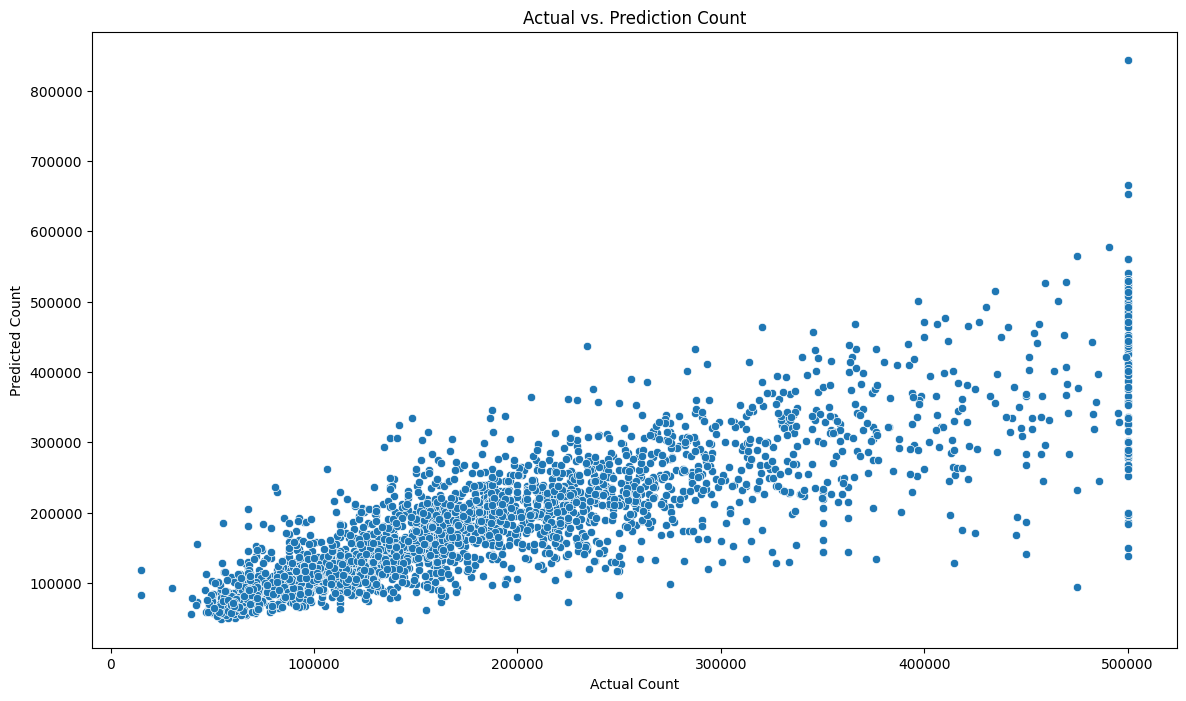

In [1107]:
plt.figure(figsize=(14, 8))
plot = sns.scatterplot(x=yTest, y=yPred).set(title='Actual vs. Prediction Count', 
                                               xlabel='Actual Count', 
                                               ylabel='Predicted Count')

Dari scatter plot di atas yang membandingkan **nilai aktual (Actual Count)** dengan **nilai prediksi (Predicted Count)**, terlihat bahwa sebagian besar titik data mengikuti pola garis diagonal dari kiri bawah ke kanan atas. Hal ini menunjukkan bahwa model **tuned XGBRegressor** mampu memprediksi nilai dengan cukup akurat — ketika nilai aktual meningkat, nilai prediksi juga meningkat secara proporsional.

Namun, terdapat beberapa penyebaran pada nilai tinggi (di atas 400.000) yang menandakan adanya sedikit deviasi atau kesalahan prediksi pada data dengan harga rumah sangat besar. Meskipun demikian, secara keseluruhan distribusi titik menunjukkan hubungan yang kuat dan konsisten antara data aktual dan hasil prediksi, mengindikasikan bahwa **model memiliki generalisasi yang baik** serta **performanya stabil pada data test set**.

##### **Prediction: Residual Analytics**

Secara keseluruhan, **analisis dan visualisasi residual** memberikan wawasan penting mengenai **kinerja model**, **pemenuhan asumsi regresi**, **keberadaan outlier**, serta **area yang masih perlu diperbaiki**.

* Analisis residual membantu menilai sejauh mana model regresi mampu memprediksi dengan akurat dan konsisten.
* Plot residual berguna untuk **mendeteksi adanya outlier** atau **titik data yang berpengaruh besar (influential points)** yang dapat memengaruhi hasil prediksi dan stabilitas model.

In [1108]:
residual = yTest - yPred

dfResidual = pd.DataFrame({'yPred': yPred,
                           'residual': residual})

dfResidualFull = pd.DataFrame({'yTest': yTest,
                               'yPred': yPred,
                               'residual': residual})
display(dfResidualFull,
        dfResidual)

,yTest,yPred,residual
7012,222500.0,186109.203125,36390.796875
1681,123400.0,160571.484375,-37171.484375
7905,214500.0,149386.796875,65113.203125
12622,116100.0,218929.109375,-102829.109375
1943,142100.0,161312.984375,-19212.984375
...,...,...,...
13206,101900.0,109268.648438,-7368.648438
12815,51000.0,63760.226562,-12760.226562
3151,206300.0,197240.750000,9059.250000
5777,98900.0,123875.843750,-24975.843750


,yPred,residual
7012,186109.203125,36390.796875
1681,160571.484375,-37171.484375
7905,149386.796875,65113.203125
12622,218929.109375,-102829.109375
1943,161312.984375,-19212.984375
...,...,...
13206,109268.648438,-7368.648438
12815,63760.226562,-12760.226562
3151,197240.750000,9059.250000
5777,123875.843750,-24975.843750


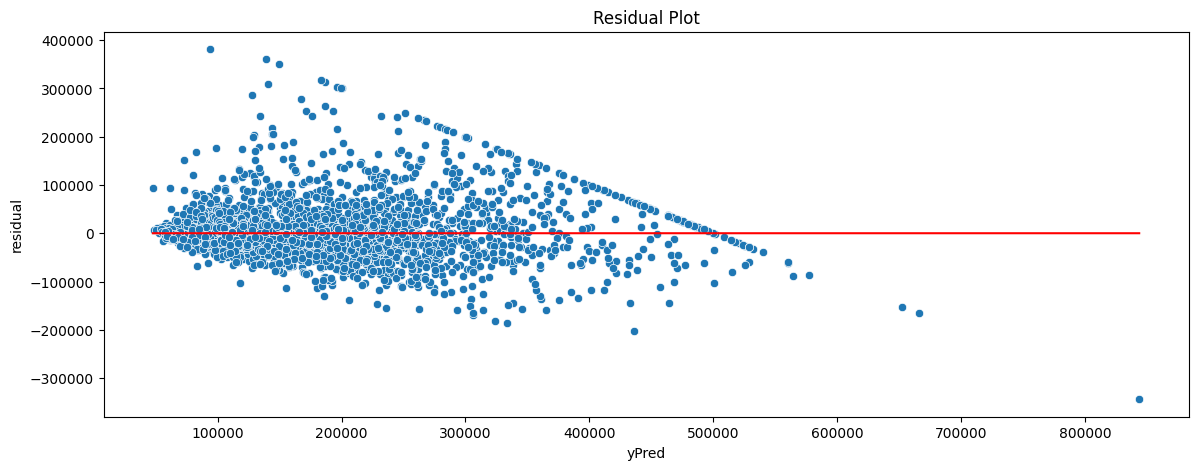

In [1109]:
plt.figure(figsize=(14,5))
sns.scatterplot(data=dfResidual, x='yPred', y='residual')
sns.lineplot(data=dfResidual, x='yPred', y=0, color='red')
plt.title('Residual Plot')
plt.show()

Dari **residual plot** di atas, terlihat bahwa sebagian besar titik residual tersebar secara acak di sekitar garis horizontal nol (warna merah), yang menandakan bahwa **model tidak memiliki pola sistematis dalam error-nya** dan mampu memprediksi dengan cukup baik. Namun, tampak adanya sedikit **pola melebar (funnel shape)** dimana variasi residual meningkat pada nilai prediksi yang lebih tinggi. Hal ini menunjukkan bahwa model **cenderung memiliki error yang lebih besar pada data dengan nilai rumah tinggi**, kemungkinan karena variasi alami harga rumah yang lebih kompleks di rentang tersebut.


Secara keseluruhan, plot ini menunjukkan bahwa **asumsi linearitas dan homoskedastisitas sebagian besar terpenuhi**, dengan hanya sedikit heteroskedastisitas pada nilai ekstrem. Model tetap dapat dianggap **stabil dan reliabel**, tetapi dapat ditingkatkan lebih lanjut dengan penanganan terhadap **outlier** atau **transformasi fitur tambahan** untuk area dengan harga rumah tinggi.

##### **Feature Importances**

Secara keseluruhan, **feature importance** berperan penting dalam membantu proses **seleksi fitur, interpretasi model, deteksi masalah data**, serta **pengembangan fitur baru** untuk meningkatkan kinerja model dan mendukung pengambilan keputusan.

* Feature importance membantu dalam memilih fitur yang paling relevan sehingga dapat meningkatkan performa model.
* Memberikan wawasan mengenai faktor-faktor utama yang memengaruhi hasil prediksi model.
* Memudahkan proses interpretasi dan penjelasan hasil model kepada pemangku kepentingan (stakeholders).
* Dapat mengungkap adanya masalah pada data atau hubungan yang tidak terduga antara fitur dan target.
* Menginspirasi proses **feature engineering** untuk menghasilkan variabel yang lebih informatif dan efektif.
* Analisis feature importance mendukung pengambilan keputusan di seluruh tahapan **machine learning pipeline**.


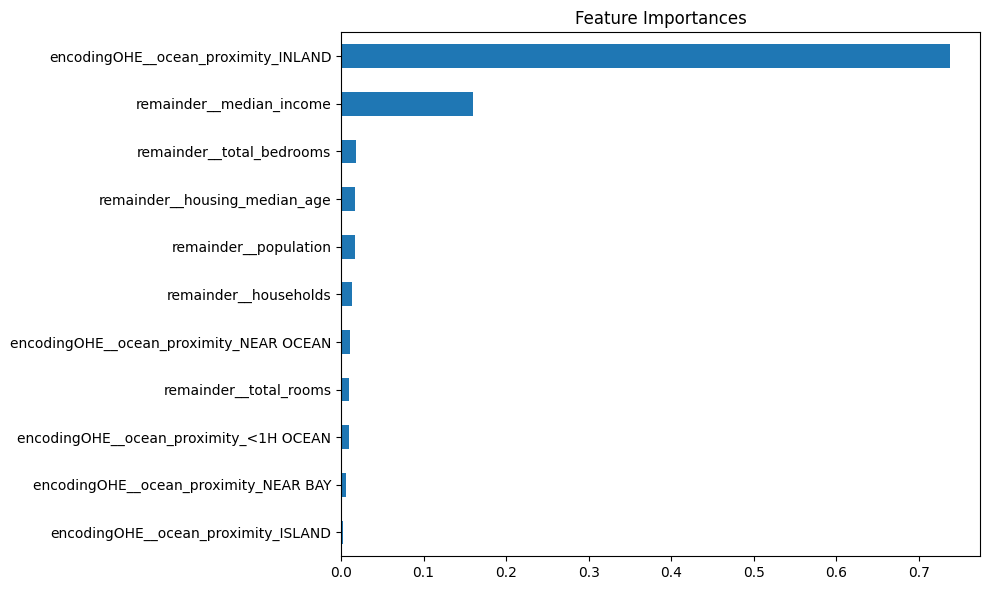

In [ ]:

fitted_preprocessor = tuned_xgbreg.named_steps['Preprocess']
feature_names = fitted_preprocessor.get_feature_names_out()
xgb_model = tuned_xgbreg.named_steps['model'].regressor_

importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', title='Feature Importances')
plt.tight_layout()
plt.show()


Dari grafik **Feature Importances** di atas, terlihat bahwa fitur **`ocean_proximity_INLAND`** memiliki pengaruh paling besar terhadap prediksi nilai median rumah (**median_house_value**) dengan kontribusi lebih dari 70%. Artinya, lokasi rumah yang berada di area **INLAND (pedalaman)** menjadi faktor paling dominan dalam menentukan harga rumah, semakin jauh dari laut, cenderung harga rumah lebih rendah. Fitur kedua yang paling berpengaruh adalah **`median_income`**, yang menunjukkan hubungan positif antara tingkat pendapatan penduduk dengan harga rumah.

Sementara itu, fitur lain seperti **`total_bedrooms`**, **`housing_median_age`**, dan **`population`** memiliki pengaruh yang jauh lebih kecil terhadap model. Variabel kategori lain seperti **`ocean_proximity_NEAR OCEAN`**, **`<1H OCEAN`**, dan **`NEAR BAY`** juga memberikan kontribusi minimal dibandingkan **INLAND**, menunjukkan bahwa kedekatan geografis dengan laut menjadi faktor penentu harga yang kuat. Secara keseluruhan, hasil ini menunjukkan bahwa **faktor lokasi dan pendapatan** merupakan dua elemen paling signifikan dalam menjelaskan variasi harga rumah, yang sejalan dengan intuisi ekonomi dan karakteristik pasar properti di wilayah tersebut.

### **Conclusion**

Berdasarkan hasil *model benchmarking*, diperoleh bahwa model **`XGBRegressor()`** (dengan nilai MAPE sekitar **23,8%** dan MAE sekitar **43.900**) serta **`RandomForestRegressor()`** (dengan MAPE sekitar **23,4%** dan MAE sekitar **43.200**) merupakan dua model terbaik setelah diterapkannya transformasi logaritmik menggunakan **`TransformedTargetRegressor()`**.
Selanjutnya, setelah dilakukan proses **hyperparameter tuning**, model **`tuned_XGBRegressor()`** menunjukkan performa terbaik dengan nilai **MAPE sebesar 23,1%** dan **MAE sebesar 42.600**, diikuti oleh **`tuned_RandomForestRegressor()`** dengan **MAPE 23,3%** dan **MAE 42.900**.

Ketika model terbaik (**tuned_XGBRegressor**) diuji menggunakan **data test set**, hasilnya menunjukkan peningkatan performa yang konsisten, dengan nilai **MAPE sekitar 22,9%**, **MAE sekitar 41.900**, dan **R² sebesar 0,82**. Hal ini menandakan bahwa model memiliki kemampuan generalisasi yang sangat baik terhadap data yang belum pernah dilihat sebelumnya, serta mampu melakukan prediksi dengan tingkat akurasi yang stabil dan reliabel.

Dalam penelitian ini, **MAPE (Mean Absolute Percentage Error)** digunakan sebagai metrik utama karena paling mudah diinterpretasikan secara persentase. Dengan demikian, model akhir mampu memperkirakan **median house value** dengan tingkat kesalahan rata-rata sekitar **22,9%**, atau setara dengan **41.000** dari nilai aktualnya.
Meskipun nilai kesalahan ini tampak cukup besar, hal tersebut masih dapat diterima mengingat rentang harga rumah yang sangat luas, mulai dari puluhan ribu hingga lebih dari 500.000 dolar. Model juga cenderung memberikan prediksi yang lebih akurat pada **rumah dengan harga menengah hingga tinggi**, sementara pada **harga rendah**, persentase kesalahan tampak lebih besar karena skala nilai yang kecil.

Berdasarkan analisis **feature importance**, fitur **`ocean_proximity_INLAND`** memiliki pengaruh paling dominan terhadap prediksi harga rumah, diikuti oleh **`median_income`**. Hal ini menunjukkan bahwa **lokasi geografis** dan **tingkat pendapatan penduduk** merupakan faktor utama yang memengaruhi nilai properti. Hasil ini sejalan dengan kondisi pasar properti di dunia nyata, di mana rumah yang berlokasi dekat pantai atau berada di kawasan dengan pendapatan tinggi umumnya memiliki harga yang lebih mahal.

Secara keseluruhan, model **`tuned XGBRegressor`** dapat dinyatakan sebagai model paling optimal dalam penelitian ini. Model ini menunjukkan tingkat akurasi dan stabilitas yang tinggi serta memiliki kemampuan generalisasi yang baik, sehingga dapat digunakan sebagai alat prediksi yang andal dalam memperkirakan **harga median rumah di California**.
Untuk pengembangan selanjutnya, model ini dapat ditingkatkan dengan menambahkan fitur-fitur spasial dan sosioekonomi lainnya, seperti jarak ke fasilitas publik, pusat kota, atau kualitas lingkungan, agar kesalahan prediksi dapat diminimalkan dan performa model meningkat lebih lanjut.


### **Recommendation**

Berdasarkan hasil analisis dan pemilihan model terbaik, berikut beberapa rekomendasi yang dapat dilakukan untuk pengembangan dan peningkatan performa model di masa mendatang:

1. **Analisis mendalam terhadap area dengan prediksi kurang akurat.**
   Berdasarkan hasil evaluasi, model cenderung memiliki tingkat kesalahan yang lebih besar pada data dengan nilai harga rumah rendah. Hal ini dapat disebabkan oleh pola data yang kurang konsisten atau adanya *noise* pada fitur-fitur tertentu. Oleh karena itu, disarankan untuk melakukan analisis lebih lanjut terhadap kelompok data tersebut guna mengidentifikasi fitur mana yang menyebabkan kebingungan dalam proses pembelajaran model. Dengan memahami penyebab ketidakakuratan tersebut, dapat dilakukan proses *feature engineering* lanjutan seperti transformasi non-linear, pembuatan *interaction features*, atau *binning* variabel untuk meningkatkan kemampuan model dalam menangkap pola pada segmen harga rendah.

2. **Penambahan variabel relevan untuk memperkaya informasi model.**
   Dataset yang digunakan saat ini relatif terbatas, terutama pada fitur-fitur spasial dan sosial ekonomi. Sebagian besar variabel yang digunakan bersifat numerik dasar atau kategorikal sederhana seperti *ocean proximity*. Untuk meningkatkan kemampuan generalisasi model terhadap area baru, disarankan menambahkan fitur tambahan seperti kepadatan penduduk, rata-rata pendapatan wilayah, jarak ke pusat kota, akses ke fasilitas umum (sekolah, rumah sakit, transportasi), serta kualitas lingkungan (polusi udara, kriminalitas, atau indeks kenyamanan). Penambahan variabel ini dapat membantu model menghasilkan prediksi yang lebih akurat dan realistis terhadap harga rumah di berbagai lokasi.

3. **Pemanfaatan model `tuned_XGBRegressor` sebagai model utama untuk prediksi.**
   Berdasarkan hasil uji performa, model **`tuned_XGBRegressor`** dengan kombinasi parameter terbaik terbukti memiliki kemampuan prediksi yang stabil dan akurat. Model ini direkomendasikan sebagai model utama untuk melakukan prediksi harga median rumah pada rentang nilai data pelatihan yang telah digunakan. Namun, perlu diperhatikan bahwa akurasi model dapat menurun apabila digunakan untuk memprediksi data yang berada jauh di luar rentang tersebut (*out-of-distribution data*). Oleh karena itu, pembaruan model secara berkala disarankan seiring bertambahnya data baru.

4. **Eksplorasi model lanjutan atau metode ensemble.**
   Meskipun model XGBoost telah memberikan hasil yang sangat baik, performa masih dapat ditingkatkan dengan pendekatan lanjutan, seperti *stacking* atau *blending* antar beberapa model (*ensemble learning*), atau menggunakan model berbasis *deep learning* seperti **Neural Networks** yang mampu menangkap hubungan non-linear yang lebih kompleks. Namun, sebelum melakukan pendekatan tersebut, perlu dilakukan penambahan fitur dan pembersihan data agar kompleksitas model sebanding dengan kualitas data yang digunakan.

5. **Eksplorasi alternatif target variabel dan segmentasi analisis.**
   Selain memprediksi *median house value* secara keseluruhan, dapat dipertimbangkan untuk melakukan segmentasi atau pemodelan berdasarkan kategori tertentu, misalnya wilayah (*coastal vs inland*) atau tingkat pendapatan. Pendekatan ini dapat menghasilkan model yang lebih spesifik dan akurat untuk konteks lokal. Selain itu, eksplorasi target tambahan (seperti rasio harga terhadap pendapatan, atau nilai properti relatif per area) dapat membuka peluang untuk analisis prediktif yang lebih beragam dan aplikatif di sektor properti.

   ***

### **Save Model**

Selanjutnya, akan dilakukan penyimpanan untuk model terbaik.

In [1112]:
# Save model
import pickle

estimator = tuned_xgbreg
estimator.fit(xTrain, yTrain)

pickle.dump(estimator, open('California Housing Price_XGB.sav', 'wb'))

In [1113]:
# Load model
filename = 'California Housing Price_XGB.sav'
loadedModel = pickle.load(open(filename, 'rb'))
loadedModel

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encodingOHE',
                                                  OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('scaler', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=XGBRegressor(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsamp...
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=np.float64(0.11),
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=np.int64(5),
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=np.int64(200),
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None, ...)))])

In [1114]:
# Run Test Model
display('MAPE',
        mean_absolute_percentage_error(yTest, loadedModel.predict(xTest)),
        'MAE',
        mean_absolute_error(yTest, loadedModel.predict(xTest)))

'MAPE'

0.2295100847705348

'MAE'

41966.053938602374

**hasil akhir yang didapatkan konsisten dan sama dengan hasil sebelumnya.**